# ANÁLISIS DE LOS FACTORES QUE DETERMINAN LA SATISFACCIÓN DEL CLIENTE EN OLIST

## Efecto del tiempo de entrega, la distancia y el tipo de producto sobre la calificación recibida

**Nombre completo:** Valentina Ramirez  
**Código estudiantil:** 330524
**Asignatura:** Aprendizaje de maquina No Supervisado  
**Universidad:** Universidad de La Sabana  
**Semestre:** 2026-I  

---

## 1. Contexto del problema

Este proyecto analiza la satisfacción del cliente en Olist, un marketplace de comercio electrónico en Brasil, con el objetivo de identificar qué factores explican mejor la calificación recibida por los compradores. La pregunta central del análisis es:

**¿Qué factores determinan la satisfacción del cliente en Olist? ¿El tiempo de entrega, la distancia o el tipo de producto explican mejor la calificación recibida?**

Para responder esta pregunta de forma consistente, la unidad de análisis será la **orden entregada con reseña**, y se construirá un dataset analítico donde cada fila represente una experiencia de compra claramente interpretable. Dado que la calificación es una variable a nivel de orden, y que la distancia y el tipo de producto pueden volverse ambiguos cuando una orden tiene múltiples vendedores o varias categorías, el análisis se enfocará en órdenes con **un solo vendedor y una sola categoría de producto**.

Esta decisión metodológica permite mantener coherencia entre la pregunta, los datos y las técnicas estadísticas que se aplicarán después. En particular, hará posible relacionar de forma directa la satisfacción del cliente con tres factores centrales: el tiempo de entrega observado, la distancia geográfica entre vendedor y cliente, y la categoría del producto comprada.

## 2. Carga de datos y preanálisis antes de limpiar

En esta sección se cargan las bases necesarias para el análisis y se realiza una revisión inicial antes de cualquier limpieza. El objetivo es entender el tamaño de cada tabla, identificar valores nulos, revisar la distribución de variables clave como el estado del pedido y la calificación del cliente, y evaluar la complejidad estructural de las órdenes. Este preanálisis es importante porque permite tomar decisiones metodológicas informadas antes de construir el dataset final.

In [3]:
# ============================================
# 2. CARGA DE DATOS Y PREANÁLISIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Ajusta esta ruta si tus archivos no están en la misma carpeta del notebook
base_path = "."

# Archivos
orders_path = os.path.join(base_path, "olist_orders_dataset.csv")
order_items_path = os.path.join(base_path, "olist_order_items_dataset.csv")
reviews_path = os.path.join(base_path, "olist_order_reviews_dataset.csv")
customers_path = os.path.join(base_path, "olist_customers_dataset.csv")
geolocation_path = os.path.join(base_path, "olist_geolocation_dataset.csv")
products_path = os.path.join(base_path, "olist_products_dataset.csv")
sellers_path = os.path.join(base_path, "olist_sellers_dataset.csv")

# Verificación de existencia
files_to_check = [
    orders_path, order_items_path, reviews_path, customers_path,
    geolocation_path, products_path, sellers_path
]

for f in files_to_check:
    print(f"{os.path.basename(f)} ->", "OK" if os.path.exists(f) else "NO ENCONTRADO")

# Carga de datos
orders = pd.read_csv(orders_path)
order_items = pd.read_csv(order_items_path)
reviews = pd.read_csv(reviews_path)
customers = pd.read_csv(customers_path)
geolocation = pd.read_csv(geolocation_path)
products = pd.read_csv(products_path)
sellers = pd.read_csv(sellers_path)

print("\nDimensiones de las bases:")
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)
print("geolocation:", geolocation.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)

olist_orders_dataset.csv -> OK
olist_order_items_dataset.csv -> OK
olist_order_reviews_dataset.csv -> OK
olist_customers_dataset.csv -> OK
olist_geolocation_dataset.csv -> OK
olist_products_dataset.csv -> OK
olist_sellers_dataset.csv -> OK

Dimensiones de las bases:
orders: (99441, 8)
order_items: (112650, 7)
reviews: (99224, 7)
customers: (99441, 5)
geolocation: (1000163, 5)
products: (32951, 9)
sellers: (3095, 4)


### 2.1 Resumen estructural de las bases

Antes de limpiar, conviene entender el tamaño relativo de las tablas y la cantidad total de valores faltantes. Esto ayuda a detectar qué bases serán más costosas de integrar y en cuáles se concentran las principales ausencias de información.

In [4]:
summary_tables = pd.DataFrame({
    "base": ["orders", "order_items", "reviews", "customers", "geolocation", "products", "sellers"],
    "filas": [
        orders.shape[0], order_items.shape[0], reviews.shape[0],
        customers.shape[0], geolocation.shape[0], products.shape[0], sellers.shape[0]
    ],
    "columnas": [
        orders.shape[1], order_items.shape[1], reviews.shape[1],
        customers.shape[1], geolocation.shape[1], products.shape[1], sellers.shape[1]
    ],
    "nulos_totales": [
        orders.isnull().sum().sum(),
        order_items.isnull().sum().sum(),
        reviews.isnull().sum().sum(),
        customers.isnull().sum().sum(),
        geolocation.isnull().sum().sum(),
        products.isnull().sum().sum(),
        sellers.isnull().sum().sum()
    ]
})

display(summary_tables)

,base,filas,columnas,nulos_totales
0,orders,99441,8,4908
1,order_items,112650,7,0
2,reviews,99224,7,145903
3,customers,99441,5,0
4,geolocation,1000163,5,0
5,products,32951,9,2448
6,sellers,3095,4,0


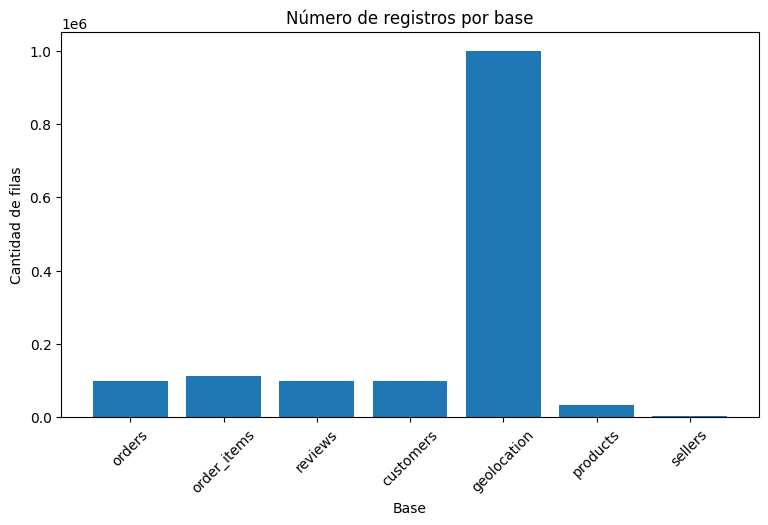

In [5]:
plt.figure(figsize=(9,5))
plt.bar(summary_tables["base"], summary_tables["filas"])
plt.title("Número de registros por base")
plt.xlabel("Base")
plt.ylabel("Cantidad de filas")
plt.xticks(rotation=45)
plt.show()

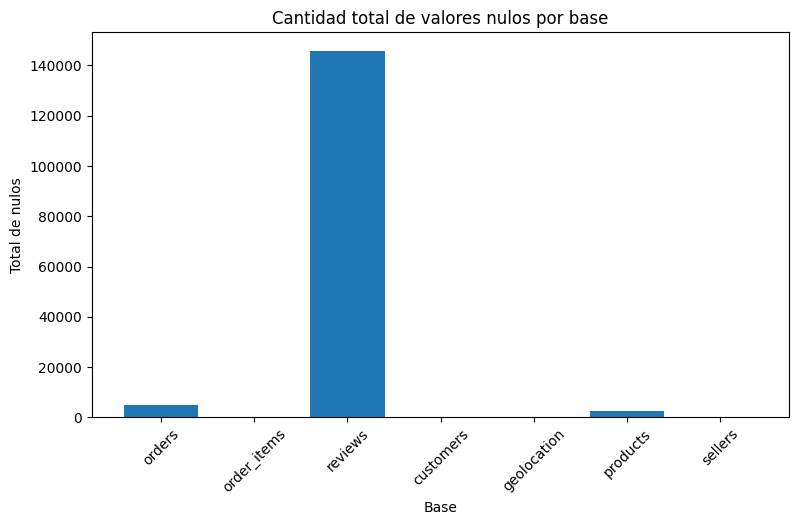

In [6]:
plt.figure(figsize=(9,5))
plt.bar(summary_tables["base"], summary_tables["nulos_totales"])
plt.title("Cantidad total de valores nulos por base")
plt.xlabel("Base")
plt.ylabel("Total de nulos")
plt.xticks(rotation=45)
plt.show()

### Interpretación 

En esta etapa debe observarse que `geolocation` es, por mucho, la base más grande del conjunto, mientras que `orders`, `reviews` y `customers` tienen tamaños comparables. También es esperable que los mayores valores nulos aparezcan en `reviews` y `products`, especialmente en campos de texto o atributos descriptivos, mientras que `customers`, `order_items` y `sellers` presentan estructuras más completas.

### 2.2 Revisión inicial de columnas y nulos clave

Antes de construir el dataset analítico, se revisan las columnas disponibles y los valores faltantes más importantes en cada base. Esta revisión permite identificar qué tablas son esenciales para la pregunta del proyecto y qué variables requerirán tratamiento posterior.

In [8]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "reviews": reviews,
    "customers": customers,
    "geolocation": geolocation,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Columnas:", list(df.columns))
    display(df.isnull().sum().sort_values(ascending=False).head(10))


ORDERS
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64


ORDER_ITEMS
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


REVIEWS
Columnas: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


...

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


PRODUCTS
Columnas: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64


SELLERS
Columnas: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

### 2.3 Variables clave antes de limpiar

Antes de construir el dataset final, se exploran dos variables fundamentales del problema: el estado de la orden y la calificación del cliente. Esto permite entender cuántas observaciones son realmente útiles para estudiar satisfacción y cómo se distribuye la evaluación general de la experiencia de compra.

In [9]:
order_status_dist = orders["order_status"].value_counts()
review_score_dist = reviews["review_score"].value_counts().sort_index()

display(order_status_dist)
display(review_score_dist)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

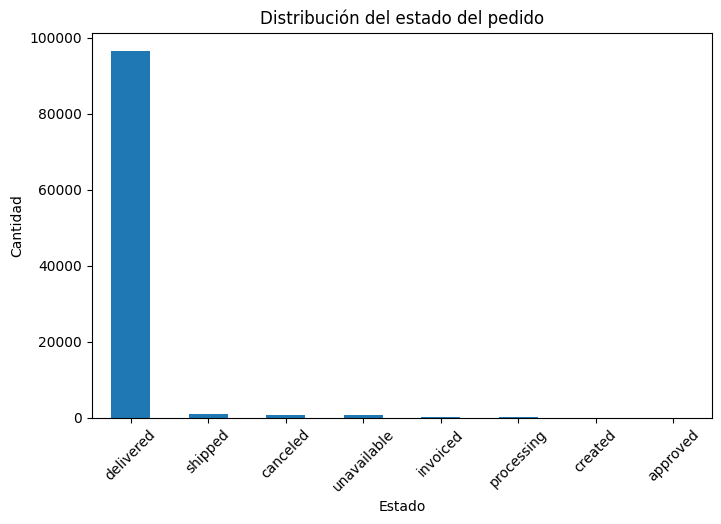

In [10]:
plt.figure(figsize=(8,5))
order_status_dist.plot(kind="bar")
plt.title("Distribución del estado del pedido")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

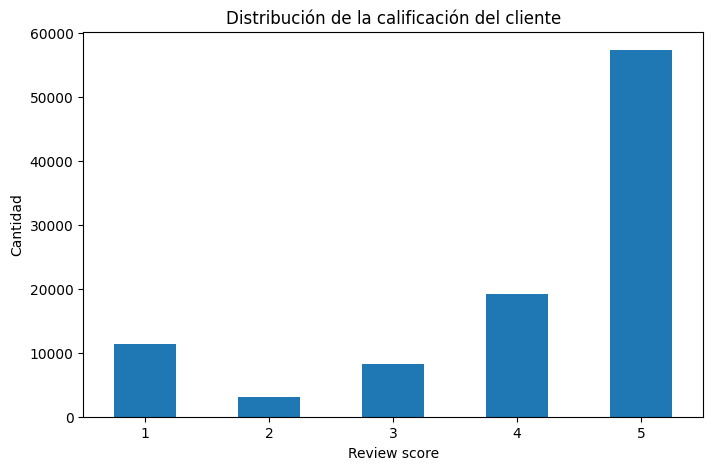

In [11]:
plt.figure(figsize=(8,5))
review_score_dist.plot(kind="bar")
plt.title("Distribución de la calificación del cliente")
plt.xlabel("Review score")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

### Interpretación 

Aquí debería verse que la mayoría de órdenes están en estado `delivered`, lo que es una buena señal para el análisis de satisfacción. También debería observarse que la distribución de `review_score` está concentrada en los puntajes altos, especialmente en 4 y 5, aunque existe un grupo no despreciable de reseñas bajas que será clave para entender la insatisfacción del cliente.

### 2.4 Complejidad estructural de las órdenes

Dado que la pregunta del proyecto quiere explicar la satisfacción usando tiempo de entrega, distancia y tipo de producto, es necesario verificar si cada orden permite representar esos factores de forma clara. Para ello, se analiza cuántos vendedores y cuántas categorías de producto tiene cada pedido. Esta revisión es fundamental, porque si una orden tiene múltiples vendedores o varias categorías, la distancia y el tipo de producto dejan de ser unívocos a nivel de orden.

In [12]:
order_items_products = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

order_complexity = (
    order_items_products
    .groupby("order_id", as_index=False)
    .agg(
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        n_categories=("product_category_name", lambda s: s.nunique(dropna=True))
    )
)

display(order_complexity.head())
display(order_complexity[["n_items", "n_sellers", "n_categories"]].describe())

,order_id,n_items,n_sellers,n_categories
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,1,1
2,000229ec398224ef6ca0657da4fc703e,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1


,n_items,n_sellers,n_categories
count,98666.000000,98666.000000,98666.000000
mean,1.141731,1.013622,0.993443
std,0.538452,0.122297,0.147849
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,21.000000,5.000000,3.000000


In [13]:
complexity_summary = pd.DataFrame({
    "criterio": [
        "Órdenes con un solo ítem",
        "Órdenes con un solo vendedor",
        "Órdenes con una sola categoría",
        "Órdenes con un solo vendedor y una sola categoría"
    ],
    "proporción": [
        (order_complexity["n_items"] == 1).mean(),
        (order_complexity["n_sellers"] == 1).mean(),
        (order_complexity["n_categories"] == 1).mean(),
        ((order_complexity["n_sellers"] == 1) & (order_complexity["n_categories"] == 1)).mean()
    ]
})

complexity_summary["porcentaje"] = (complexity_summary["proporción"] * 100).round(2)
display(complexity_summary)

,criterio,proporción,porcentaje
0,Órdenes con un solo ítem,0.900645,90.06
1,Órdenes con un solo vendedor,0.987047,98.70
2,Órdenes con una sola categoría,0.978554,97.86
3,Órdenes con un solo vendedor y una sola categoría,0.971368,97.14


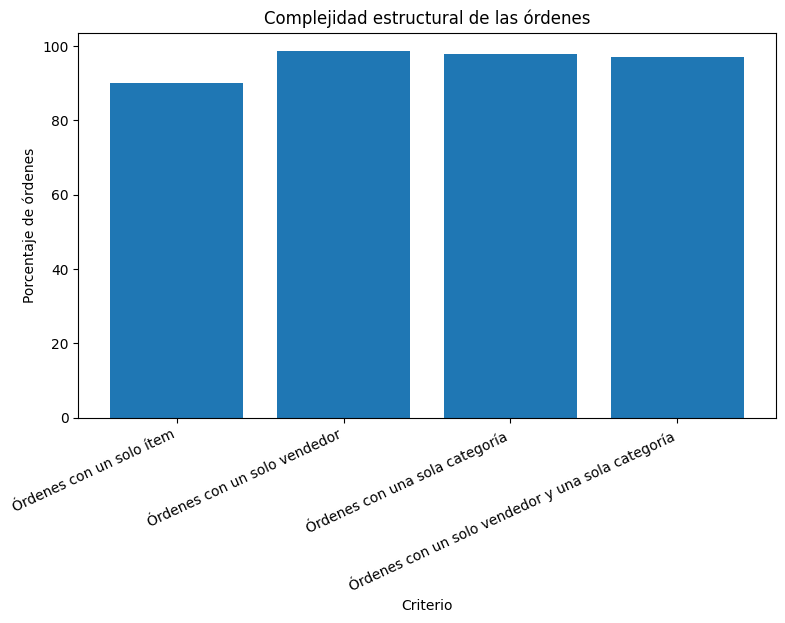

In [14]:
plt.figure(figsize=(9,5))
plt.bar(complexity_summary["criterio"], complexity_summary["porcentaje"])
plt.title("Complejidad estructural de las órdenes")
plt.xlabel("Criterio")
plt.ylabel("Porcentaje de órdenes")
plt.xticks(rotation=25, ha="right")
plt.show()

### Interpretación metodológica

Esta sección es clave para decidir la unidad de análisis. Si una proporción alta de órdenes tiene un solo vendedor y una sola categoría, entonces es viable construir un dataset analítico a nivel de orden sin introducir ambigüedad en la distancia o en el tipo de producto. Si, por el contrario, predominan órdenes con múltiples vendedores o categorías, sería necesario cambiar la unidad de análisis o redefinir la pregunta del proyecto.

## Conclusión del preanálisis

El preanálisis confirma que las bases seleccionadas permiten responder de forma consistente la pregunta del proyecto. En primer lugar, la mayoría de los pedidos se encuentra en estado `delivered`, lo que garantiza una base suficiente para estudiar satisfacción real post-entrega. En segundo lugar, la distribución de `review_score` muestra una fuerte concentración en calificaciones altas, aunque también existe un grupo relevante de reseñas negativas que permitirá modelar la insatisfacción del cliente.

El hallazgo metodológico más importante es la estructura de las órdenes: aunque no todas contienen un solo ítem, una proporción muy alta sí presenta **un solo vendedor y una sola categoría de producto**. Esto justifica trabajar a nivel de orden sin perder interpretabilidad en dos factores clave del proyecto: la distancia geográfica entre vendedor y cliente, y el tipo de producto asociado a la compra. Con base en estos resultados, en la siguiente sección se construirá un dataset analítico filtrado y consistente que servirá como base única para todo el análisis posterior.

## 3. Limpieza y construcción del dataset analítico

En esta sección se construye el dataset analítico final que se utilizará en todo el proyecto. El objetivo es pasar de varias tablas relacionales a una sola base consistente a nivel de orden, donde cada fila represente una experiencia de compra claramente interpretable. Para lograrlo, se convertirán las fechas al formato adecuado, se consolidará la geolocalización, se depurarán las reseñas duplicadas, se enriquecerán los ítems con información de producto, y finalmente se filtrarán únicamente las órdenes entregadas con reseña, un solo vendedor, una sola categoría conocida y coordenadas válidas tanto para el cliente como para el vendedor.

### 3.1 Copias de trabajo y conversión de fechas

Antes de limpiar, se crean copias de las bases originales para preservar la versión cargada inicialmente. Luego se convierten a formato datetime las columnas de fecha necesarias para calcular tiempos de entrega y ordenar correctamente las reseñas.

In [15]:
# Copias de trabajo
orders_clean = orders.copy()
order_items_clean = order_items.copy()
reviews_clean = reviews.copy()
customers_clean = customers.copy()
geolocation_clean = geolocation.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()

# Conversión de fechas en orders
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

# Conversión de fechas en reviews
date_cols_reviews = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_cols_reviews:
    reviews_clean[col] = pd.to_datetime(reviews_clean[col], errors="coerce")

print("Conversión de fechas completada.")
print("\nTipos de datos en orders:")
display(orders_clean[date_cols_orders].dtypes)

print("\nTipos de datos en reviews:")
display(reviews_clean[date_cols_reviews].dtypes)

Conversión de fechas completada.

Tipos de datos en orders:


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


Tipos de datos en reviews:


review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

### 3.2 Consolidación de geolocalización

La base de geolocalización puede tener múltiples registros para un mismo prefijo de código postal. Para evitar duplicaciones al unirla con clientes y vendedores, se construye una versión agregada con una sola latitud y longitud promedio por código postal.

In [16]:
geo_grouped = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean")
    )
)

print("Tamaño original de geolocation:", geolocation_clean.shape)
print("Tamaño agrupado de geolocation:", geo_grouped.shape)
display(geo_grouped.head())

print("\nDuplicados en geolocation agrupada:")
print(geo_grouped["geolocation_zip_code_prefix"].duplicated().sum())

Tamaño original de geolocation: (1000163, 5)
Tamaño agrupado de geolocation: (19015, 3)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733



Duplicados en geolocation agrupada:
0


### 3.3 Integración de coordenadas para clientes y vendedores

Para poder calcular la distancia geográfica real entre el origen y el destino del pedido, se unen clientes y vendedores con la base de geolocalización agrupada. Así, cada cliente y cada vendedor quedan asociados a coordenadas promedio según su código postal.

In [17]:
customers_geo = customers_clean.merge(
    geo_grouped.rename(columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng"
    }),
    on="customer_zip_code_prefix",
    how="left"
)

sellers_geo = sellers_clean.merge(
    geo_grouped.rename(columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng"
    }),
    on="seller_zip_code_prefix",
    how="left"
)

print("Tamaño de customers_geo:", customers_geo.shape)
print("Tamaño de sellers_geo:", sellers_geo.shape)

print("\nNulos en coordenadas del cliente:")
display(customers_geo[["customer_lat", "customer_lng"]].isnull().sum())

print("\nNulos en coordenadas del vendedor:")
display(sellers_geo[["seller_lat", "seller_lng"]].isnull().sum())

Tamaño de customers_geo: (99441, 7)
Tamaño de sellers_geo: (3095, 6)

Nulos en coordenadas del cliente:


customer_lat    278
customer_lng    278
dtype: int64


Nulos en coordenadas del vendedor:


seller_lat    7
seller_lng    7
dtype: int64

### 3.4 Preparación de reseñas únicas por orden

Aunque la mayoría de órdenes tiene una sola reseña, existen algunos casos repetidos por `order_id`. Como la unidad de análisis será una orden por fila, se conserva una única reseña por pedido, priorizando la primera registrada temporalmente.

In [18]:
reviews_unique = (
    reviews_clean
    .sort_values(["order_id", "review_answer_timestamp"])
    .drop_duplicates(subset="order_id", keep="first")
    .copy()
)

print("Tamaño original de reviews:", reviews_clean.shape)
print("Tamaño de reviews_unique:", reviews_unique.shape)

print("\nDuplicados por order_id en reviews_unique:")
print(reviews_unique["order_id"].duplicated().sum())

display(reviews_unique.head())

Tamaño original de reviews: (99224, 7)
Tamaño de reviews_unique: (98673, 7)

Duplicados por order_id en reviews_unique:
0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
51963,97ca439bc427b48bc1cd7177abe71365,00010242fe8c5a6d1ba2dd792cb16214,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
27823,7b07bacd811c4117b742569b04ce3580,00018f77f2f0320c557190d7a144bdd3,4,NaN,NaN,2017-05-13,2017-05-15 11:34:13
4218,0c5b33dea94867d1ac402749e5438e8b,000229ec398224ef6ca0657da4fc703e,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
38844,f4028d019cb58564807486a6aaf33817,00024acbcdf0a6daa1e931b038114c75,4,NaN,NaN,2018-08-15,2018-08-15 16:39:01
55676,940144190dcba6351888cafa43f3a3a5,00042b26cf59d7ce69dfabb4e55b4fd9,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


### 3.5 Enriquecimiento de ítems y filtro estructural

A continuación se integran los ítems de la orden con la información de producto. Esta unión permite incorporar la categoría del producto y el peso. Luego se construye una versión más estricta de la complejidad estructural de las órdenes, exigiendo no solo un solo vendedor y una sola categoría, sino además que la categoría del producto sea conocida. Esta decisión garantiza que la variable “tipo de producto” sea realmente interpretable en el análisis posterior.

In [19]:
order_items_enriched = order_items_clean.merge(
    products_clean[["product_id", "product_category_name", "product_weight_g"]],
    on="product_id",
    how="left"
)

order_structure_strict = (
    order_items_enriched
    .groupby("order_id", as_index=False)
    .agg(
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        n_categories=("product_category_name", lambda s: s.nunique(dropna=True)),
        n_missing_category=("product_category_name", lambda s: s.isna().sum())
    )
)

valid_structural_orders = order_structure_strict[
    (order_structure_strict["n_sellers"] == 1) &
    (order_structure_strict["n_categories"] == 1) &
    (order_structure_strict["n_missing_category"] == 0)
].copy()

print("Órdenes totales en order_structure_strict:", order_structure_strict.shape[0])
print("Órdenes estructuralmente válidas:", valid_structural_orders.shape[0])
print("Porcentaje retenido:", round(valid_structural_orders.shape[0] / order_structure_strict.shape[0] * 100, 2), "%")

display(order_structure_strict.head())

Órdenes totales en order_structure_strict: 98666
Órdenes estructuralmente válidas: 95810
Porcentaje retenido: 97.11 %


,order_id,n_items,n_sellers,n_categories,n_missing_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,0
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,0
2,000229ec398224ef6ca0657da4fc703e,1,1,1,0
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,0


### 3.6 Agregación de los ítems a nivel de orden

Una vez definidas las órdenes estructuralmente válidas, se agregan los ítems a nivel de orden para construir variables económicas y logísticas consolidadas. Esta tabla resumida permitirá unir precio total, flete total, número de ítems, peso acumulado, vendedor y categoría con la información central del pedido.

In [20]:
def first_nonnull(series):
    s = series.dropna()
    return s.iloc[0] if not s.empty else np.nan

order_level_items = (
    order_items_enriched[
        order_items_enriched["order_id"].isin(valid_structural_orders["order_id"])
    ]
    .groupby("order_id", as_index=False)
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        items_count=("order_item_id", "count"),
        seller_id=("seller_id", first_nonnull),
        product_category_name=("product_category_name", first_nonnull),
        total_weight_g=("product_weight_g", lambda s: s.sum(min_count=1))
    )
)

print("Tamaño de order_level_items:", order_level_items.shape)
print("Duplicados por order_id:", order_level_items["order_id"].duplicated().sum())

display(order_level_items.head())

Tamaño de order_level_items: (95810, 7)
Duplicados por order_id: 0


,order_id,total_price,total_freight,items_count,seller_id,product_category_name,total_weight_g
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,48436dade18ac8b2bce089ec2a041202,cool_stuff,650.0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,30000.0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,3050.0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,9d7a1d34a5052409006425275ba1c2b4,perfumaria,200.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,3750.0


### 3.7 Filtrado de órdenes entregadas con información logística válida

Como la satisfacción del cliente solo puede interpretarse después de la entrega, se conservan exclusivamente las órdenes entregadas que tengan fecha de compra, fecha real de entrega y fecha estimada de entrega disponibles. Esta decisión garantiza consistencia en el cálculo del tiempo de entrega y la tardanza.

In [21]:
orders_delivered = orders_clean[
    (orders_clean["order_status"] == "delivered") &
    (orders_clean["order_purchase_timestamp"].notna()) &
    (orders_clean["order_delivered_customer_date"].notna()) &
    (orders_clean["order_estimated_delivery_date"].notna())
].copy()

print("Tamaño original de orders:", orders_clean.shape)
print("Tamaño de orders_delivered:", orders_delivered.shape)

print("\nEstados presentes:")
display(orders_delivered["order_status"].value_counts())

print("\nNulos en fechas clave:")
display(
    orders_delivered[
        [
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ].isnull().sum()
)

Tamaño original de orders: (99441, 8)
Tamaño de orders_delivered: (96470, 8)

Estados presentes:


order_status
delivered    96470
Name: count, dtype: int64


Nulos en fechas clave:


order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

### 3.8 Construcción del dataset analítico

En este paso se integran todas las piezas preparadas anteriormente. La tabla de órdenes entregadas se une con la reseña única, la agregación de ítems, la ubicación del cliente y la ubicación del vendedor. El resultado será una base a nivel de orden, lista para construir variables analíticas y calcular distancia real entre origen y destino.

In [22]:
stage_1 = orders_delivered.merge(
    reviews_unique[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

stage_2 = stage_1.merge(
    order_level_items,
    on="order_id",
    how="inner"
)

stage_3 = (
    stage_2
    .merge(
        customers_geo[
            ["customer_id", "customer_city", "customer_state", "customer_lat", "customer_lng"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        sellers_geo[
            ["seller_id", "seller_city", "seller_state", "seller_lat", "seller_lng"]
        ],
        on="seller_id",
        how="left"
    )
)

print("stage_1:", stage_1.shape)
print("stage_2:", stage_2.shape)
print("stage_3:", stage_3.shape)

display(stage_3.head())

stage_1: (95824, 9)
stage_2: (93059, 15)
stage_3: (93059, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,total_price,total_freight,items_count,seller_id,product_category_name,total_weight_g,customer_city,customer_state,customer_lat,customer_lng,seller_city,seller_state,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,29.99,8.72,1,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,500.0,sao paulo,SP,-23.576983,-46.587161,maua,SP,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,118.70,22.76,1,289cdb325fb7e7f891c38608bf9e0962,perfumaria,400.0,barreiras,BA,-12.177924,-44.660711,belo horizonte,SP,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,159.90,19.22,1,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,420.0,vianopolis,GO,-16.745150,-48.514783,guariba,SP,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,45.00,27.20,1,66922902710d126a0e7d26b0e3805106,pet_shop,450.0,sao goncalo do amarante,RN,-5.774190,-35.271143,belo horizonte,MG,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,19.90,8.72,1,2c9e548be18521d1c43cde1c582c6de8,papelaria,250.0,santo andre,SP,-23.676370,-46.514627,mogi das cruzes,SP,-23.543395,-46.262086


### 3.9 Filtro final de consistencia

Finalmente, se eliminan las observaciones que todavía presenten ambigüedad o información incompleta para la pregunta del proyecto. En particular, se conservan únicamente las órdenes con coordenadas válidas de cliente y vendedor, categoría conocida, precio positivo y variables listas para construir distancia y tiempos logísticos.

In [23]:
analytic_dataset = stage_3.dropna(
    subset=[
        "customer_lat", "customer_lng",
        "seller_lat", "seller_lng",
        "product_category_name",
        "total_price", "total_freight"
    ]
).copy()

analytic_dataset = analytic_dataset[analytic_dataset["total_price"] > 0].copy()

print("Tamaño de analytic_dataset antes de variables derivadas:", analytic_dataset.shape)

print("\nNulos principales:")
display(
    analytic_dataset[
        [
            "customer_lat", "customer_lng",
            "seller_lat", "seller_lng",
            "product_category_name",
            "total_price", "total_freight"
        ]
    ].isnull().sum()
)

Tamaño de analytic_dataset antes de variables derivadas: (92596, 23)

Nulos principales:


customer_lat             0
customer_lng             0
seller_lat               0
seller_lng               0
product_category_name    0
total_price              0
total_freight            0
dtype: int64

### 3.10 Creación de variables derivadas

Con la base analítica ya construida, se crean las variables centrales del proyecto: tiempo de entrega, tardanza, entrega tardía, proporción del flete, reseña negativa y distancia geográfica real entre vendedor y cliente. La distancia se calcula con la fórmula de Haversine, que es adecuada para coordenadas geográficas expresadas en latitud y longitud.

In [24]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

analytic_dataset["delivery_days"] = (
    analytic_dataset["order_delivered_customer_date"] -
    analytic_dataset["order_purchase_timestamp"]
).dt.days

analytic_dataset["delay_days"] = (
    analytic_dataset["order_delivered_customer_date"] -
    analytic_dataset["order_estimated_delivery_date"]
).dt.days

analytic_dataset["is_late"] = (analytic_dataset["delay_days"] > 0).astype(int)

analytic_dataset["freight_ratio"] = (
    analytic_dataset["total_freight"] / analytic_dataset["total_price"]
)

analytic_dataset["negative_review"] = (
    analytic_dataset["review_score"] <= 2
).astype(int)

analytic_dataset["total_weight_kg"] = analytic_dataset["total_weight_g"] / 1000

analytic_dataset["distance_km"] = haversine_vectorized(
    analytic_dataset["seller_lat"].values,
    analytic_dataset["seller_lng"].values,
    analytic_dataset["customer_lat"].values,
    analytic_dataset["customer_lng"].values
)

# Limpieza final mínima de coherencia
analytic_dataset = analytic_dataset[
    analytic_dataset["delivery_days"].notna() &
    analytic_dataset["delay_days"].notna() &
    analytic_dataset["distance_km"].notna() &
    analytic_dataset["freight_ratio"].notna()
].copy()

analytic_dataset = analytic_dataset[analytic_dataset["delivery_days"] >= 0].copy()
analytic_dataset["freight_ratio"] = analytic_dataset["freight_ratio"].replace([np.inf, -np.inf], np.nan)
analytic_dataset = analytic_dataset[analytic_dataset["freight_ratio"].notna()].copy()

print("Tamaño final de analytic_dataset:", analytic_dataset.shape)

display(
    analytic_dataset[
        [
            "order_id", "review_score", "product_category_name",
            "delivery_days", "delay_days", "is_late",
            "total_price", "total_freight", "freight_ratio",
            "distance_km"
        ]
    ].head()
)

Tamaño final de analytic_dataset: (92596, 30)


,order_id,review_score,product_category_name,delivery_days,delay_days,is_late,total_price,total_freight,freight_ratio,distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,4,utilidades_domesticas,8,-8,0,29.99,8.72,0.290764,18.576110
1,53cdb2fc8bc7dce0b6741e2150273451,4,perfumaria,13,-6,0,118.70,22.76,0.191744,851.495069
2,47770eb9100c2d0c44946d9cf07ec65d,5,automotivo,9,-18,0,159.90,19.22,0.120200,514.410666
3,949d5b44dbf5de918fe9c16f97b45f8a,5,pet_shop,13,-13,0,45.00,27.20,0.604444,1822.226336
4,ad21c59c0840e6cb83a9ceb5573f8159,5,papelaria,2,-10,0,19.90,8.72,0.438191,29.676625


### 3.11 Verificación de calidad del dataset final

Antes de pasar al análisis exploratorio post-limpieza, se verifica que la base final tenga una sola fila por orden, que las variables esenciales no tengan nulos y que la selección metodológica haya preservado una cantidad suficiente de observaciones para el análisis.

In [25]:
print("Duplicados por order_id:", analytic_dataset["order_id"].duplicated().sum())

key_vars = [
    "review_score", "product_category_name", "delivery_days",
    "delay_days", "freight_ratio", "distance_km",
    "seller_lat", "seller_lng", "customer_lat", "customer_lng"
]

print("\nNulos en variables clave:")
display(analytic_dataset[key_vars].isnull().sum().sort_values(ascending=False))

print("\nResumen descriptivo de variables cuantitativas:")
display(
    analytic_dataset[
        ["review_score", "delivery_days", "delay_days", "total_price", "total_freight", "freight_ratio", "distance_km"]
    ].describe()
)

Duplicados por order_id: 0

Nulos en variables clave:


review_score             0
product_category_name    0
delivery_days            0
delay_days               0
freight_ratio            0
distance_km              0
seller_lat               0
seller_lng               0
customer_lat             0
customer_lng             0
dtype: int64


Resumen descriptivo de variables cuantitativas:


,review_score,delivery_days,delay_days,total_price,total_freight,freight_ratio,distance_km
count,92596.000000,92596.000000,92596.000000,92596.000000,92596.000000,92596.000000,92596.000000
mean,4.176174,12.087390,-11.856959,135.870225,22.443797,0.308461,601.754051
std,1.266920,9.493948,10.120458,207.830865,21.159087,0.312283,594.643168
min,1.000000,0.000000,-147.000000,0.850000,0.000000,0.000000,0.000000
25%,4.000000,6.000000,-17.000000,45.600000,13.750000,0.132010,186.641379
50%,5.000000,10.000000,-12.000000,84.990000,17.060000,0.224374,434.458566
75%,5.000000,15.000000,-7.000000,149.900000,23.630000,0.380836,799.829664
max,5.000000,208.000000,188.000000,13440.000000,1794.960000,21.447059,8677.911622


### 3.12 Trazabilidad del proceso de filtrado

Para cerrar la sección, se resume cuántas órdenes se conservaron en cada etapa del proceso. Esta tabla es útil para justificar metodológicamente la construcción del dataset final y explicar con transparencia cuánto se redujo la muestra al exigir una unidad de análisis más consistente.

In [26]:
pipeline_summary = pd.DataFrame({
    "Etapa": [
        "Órdenes totales",
        "Órdenes entregadas con fechas válidas",
        "Órdenes entregadas con reseña",
        "Órdenes estructuralmente válidas",
        "Órdenes con cliente y vendedor integrados",
        "Dataset analítico final"
    ],
    "Órdenes": [
        orders["order_id"].nunique(),
        orders_delivered["order_id"].nunique(),
        stage_1["order_id"].nunique(),
        order_level_items["order_id"].nunique(),
        stage_3["order_id"].nunique(),
        analytic_dataset["order_id"].nunique()
    ]
})

pipeline_summary["% respecto al total"] = (
    pipeline_summary["Órdenes"] / pipeline_summary.loc[0, "Órdenes"] * 100
).round(2)

display(pipeline_summary)

,Etapa,Órdenes,% respecto al total
0,Órdenes totales,99441,100.00
1,Órdenes entregadas con fechas válidas,96470,97.01
2,Órdenes entregadas con reseña,95824,96.36
3,Órdenes estructuralmente válidas,95810,96.35
4,Órdenes con cliente y vendedor integrados,93059,93.58
5,Dataset analítico final,92596,93.12


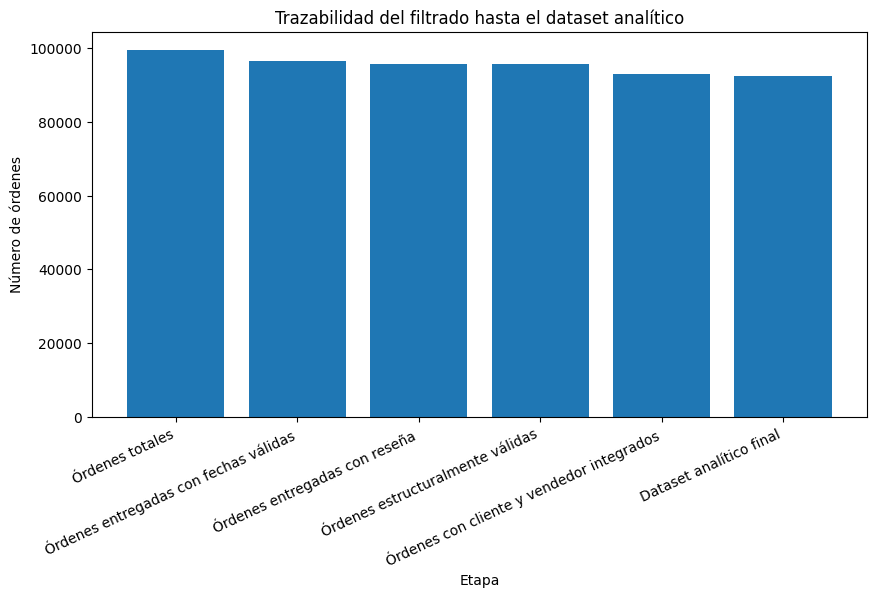

In [27]:
plt.figure(figsize=(10,5))
plt.bar(pipeline_summary["Etapa"], pipeline_summary["Órdenes"])
plt.title("Trazabilidad del filtrado hasta el dataset analítico")
plt.xlabel("Etapa")
plt.ylabel("Número de órdenes")
plt.xticks(rotation=25, ha="right")
plt.show()

### 3.13 Revisión rápida después de limpiar

Antes del análisis exploratorio formal, se revisan dos elementos del dataset final: la distribución de la calificación y las categorías de producto más frecuentes. Esto permite comprobar que la base final sigue siendo informativa y que conserva variedad suficiente para estudiar satisfacción, distancia y tipo de producto.

product_category_name
cama_mesa_banho           8772
beleza_saude              8477
esporte_lazer             7351
informatica_acessorios    6367
moveis_decoracao          5974
utilidades_domesticas     5536
relogios_presentes        5358
telefonia                 3994
automotivo                3724
brinquedos                3676
Name: count, dtype: int64

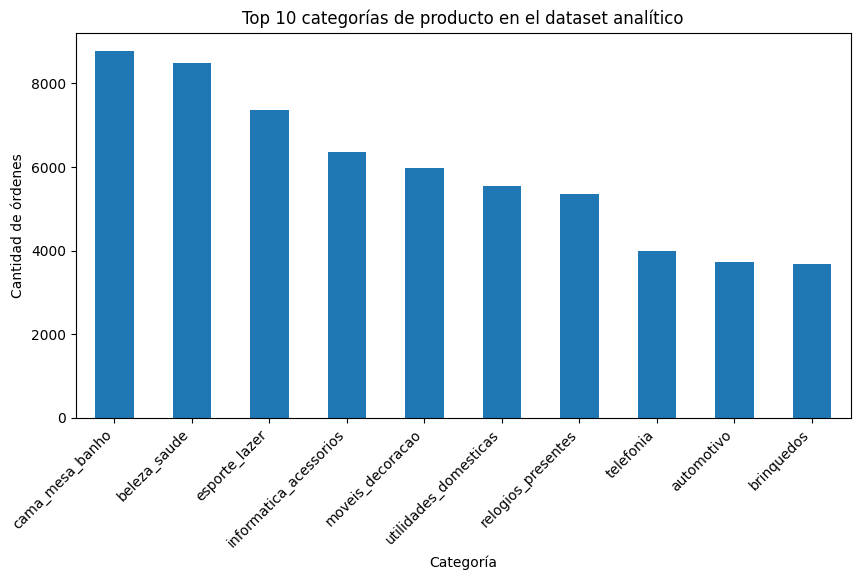

In [29]:
top_categories = analytic_dataset["product_category_name"].value_counts().head(10)

display(top_categories)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 10 categorías de producto en el dataset analítico")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de órdenes")
plt.xticks(rotation=45, ha="right")
plt.show()

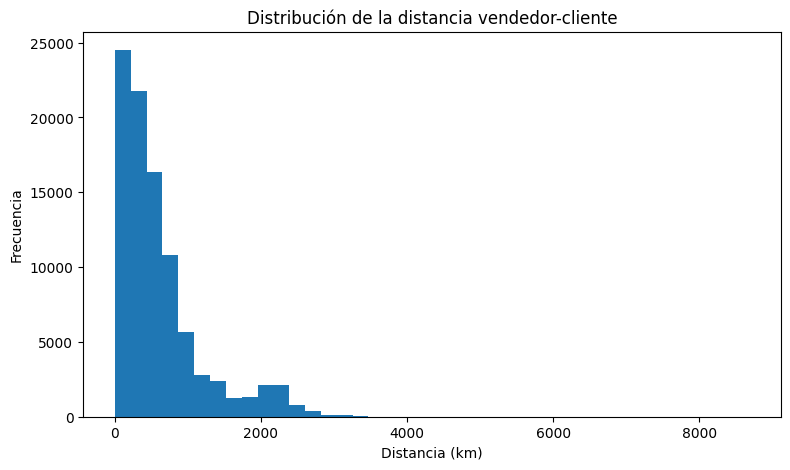

In [30]:
plt.figure(figsize=(9,5))
plt.hist(analytic_dataset["distance_km"], bins=40)
plt.title("Distribución de la distancia vendedor-cliente")
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.show()

## Conclusión de la limpieza y construcción del dataset analítico

Después del proceso de limpieza e integración, se obtuvo un dataset analítico consistente a nivel de orden, donde cada observación representa una experiencia de compra con reseña, un solo vendedor, una sola categoría de producto conocida y coordenadas válidas tanto para el origen como para el destino. Esta base permite analizar de manera coherente el efecto del tiempo de entrega, la distancia geográfica y el tipo de producto sobre la satisfacción del cliente, evitando ambigüedades estructurales que habrían dificultado la interpretación de los resultados.

## 4. Análisis exploratorio después de la limpieza

En esta sección se analiza el comportamiento del dataset analítico final una vez completada la limpieza. El objetivo es estudiar cómo se distribuye la satisfacción del cliente y explorar de manera comparativa los tres factores centrales del proyecto: el tiempo de entrega, la distancia geográfica entre vendedor y cliente, y el tipo de producto. A diferencia del preanálisis inicial, esta etapa trabaja sobre una base ya consistente a nivel de orden, donde cada observación representa una experiencia de compra con reseña, una sola categoría de producto conocida y una distancia geográfica interpretable. Los hallazgos de esta sección permitirán identificar cuál de los tres factores parece tener mayor poder explicativo sobre la calificación recibida y servirán como base para las técnicas estadísticas posteriores.

### 4.1 Preparación de variables para visualización

Antes de graficar, se crean algunas variables auxiliares que facilitan la interpretación de los resultados. En particular, se construye un nivel categórico de satisfacción y se generan versiones recortadas de algunas variables continuas para visualizar mejor su comportamiento sin que los valores extremos oculten la estructura central de los datos.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

analysis_df = analytic_dataset.copy()

def satisfaction_label(score):
    if score <= 2:
        return "Negativa"
    elif score == 3:
        return "Neutral"
    else:
        return "Positiva"

analysis_df["satisfaction_level"] = analysis_df["review_score"].apply(satisfaction_label)

# Versiones recortadas para visualización
p99_delivery = analysis_df["delivery_days"].quantile(0.99)
p01_delay = analysis_df["delay_days"].quantile(0.01)
p99_delay = analysis_df["delay_days"].quantile(0.99)
p99_distance = analysis_df["distance_km"].quantile(0.99)
p99_freight = analysis_df["freight_ratio"].quantile(0.99)

analysis_df["delivery_days_capped"] = analysis_df["delivery_days"].clip(upper=p99_delivery)
analysis_df["delay_days_capped"] = analysis_df["delay_days"].clip(lower=p01_delay, upper=p99_delay)
analysis_df["distance_km_capped"] = analysis_df["distance_km"].clip(upper=p99_distance)
analysis_df["freight_ratio_capped"] = analysis_df["freight_ratio"].clip(upper=p99_freight)

print("Percentiles clave:")
print("p99 delivery_days:", p99_delivery)
print("p01 delay_days:", p01_delay)
print("p99 delay_days:", p99_delay)
print("p99 distance_km:", p99_distance)
print("p99 freight_ratio:", p99_freight)

Percentiles clave:
p99 delivery_days: 45.0
p01 delay_days: -36.0
p99 delay_days: 18.0
p99 distance_km: 2484.972106707705
p99 freight_ratio: 1.4619459316467427


### 4.2 Distribución de la satisfacción del cliente

La primera pregunta después de la limpieza es si la base final sigue reflejando un patrón claro de satisfacción del cliente. Para responderla, se revisa la distribución de la calificación original y su agrupación en niveles de satisfacción. Esto permite comprobar si la limpieza alteró de forma importante la estructura del fenómeno o si la base final conserva una señal interpretativamente útil.

,Frecuencia,Porcentaje (%)
review_score,,
1,8644,9.34
2,2710,2.93
3,7598,8.21
4,18381,19.85
5,55263,59.68


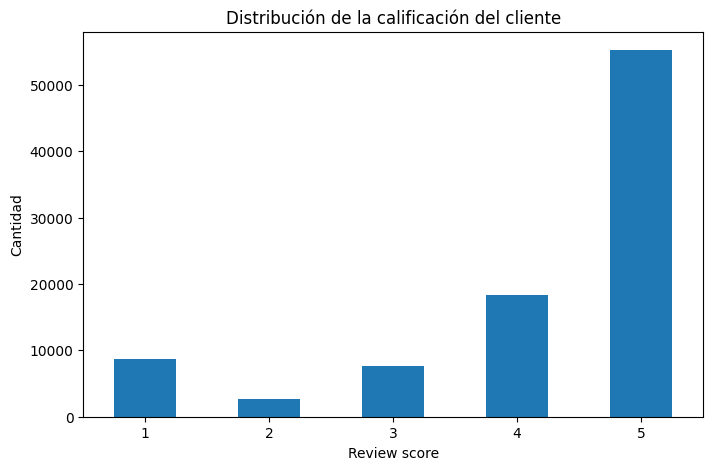

In [32]:
review_dist = analysis_df["review_score"].value_counts().sort_index()
review_pct = (review_dist / review_dist.sum() * 100).round(2)

display(pd.DataFrame({
    "Frecuencia": review_dist,
    "Porcentaje (%)": review_pct
}))

plt.figure(figsize=(8,5))
review_dist.plot(kind="bar")
plt.title("Distribución de la calificación del cliente")
plt.xlabel("Review score")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

,Frecuencia,Porcentaje (%)
satisfaction_level,,
Positiva,73644,79.53
Negativa,11354,12.26
Neutral,7598,8.21


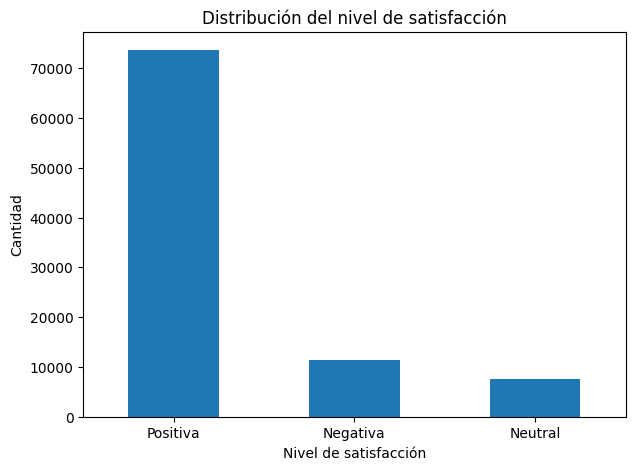

In [33]:
sat_dist = analysis_df["satisfaction_level"].value_counts()
sat_pct = (sat_dist / sat_dist.sum() * 100).round(2)

display(pd.DataFrame({
    "Frecuencia": sat_dist,
    "Porcentaje (%)": sat_pct
}))

plt.figure(figsize=(7,5))
sat_dist.plot(kind="bar")
plt.title("Distribución del nivel de satisfacción")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

### Interpretación

En el dataset analítico final, la satisfacción sigue concentrándose en niveles altos. La categoría **Positiva** reúne aproximadamente el **79.53%** de las órdenes, mientras que las reseñas **Negativas** representan cerca del **12.26%** y las **Neutrales** el **8.21%**. Esto indica que la limpieza no destruyó la estructura general del fenómeno: la mayoría de las experiencias de compra sigue siendo favorable, pero el grupo de clientes insatisfechos continúa siendo suficientemente grande como para justificar un análisis específico de sus determinantes.

### 4.3 Tiempo de entrega y satisfacción

Dado que la logística es una dimensión central de la pregunta del proyecto, se estudia en primer lugar el comportamiento del tiempo de entrega. Esta variable será además la candidata principal para el análisis por máxima verosimilitud, por lo que conviene entender desde ahora su forma, su dispersión y su relación con la satisfacción.

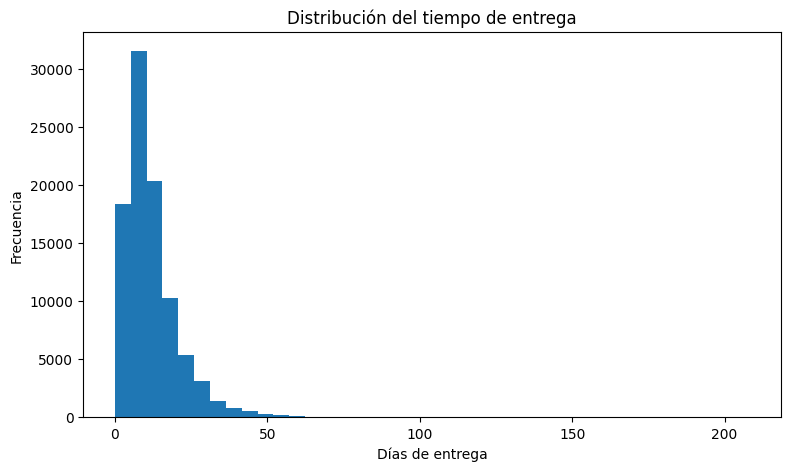

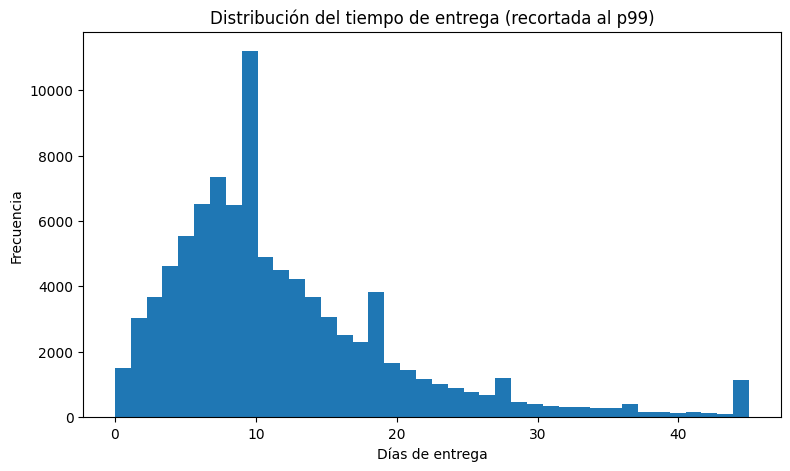

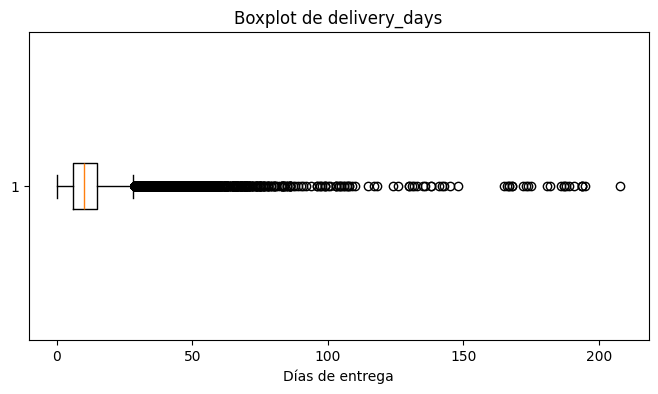

In [34]:
plt.figure(figsize=(9,5))
plt.hist(analysis_df["delivery_days"], bins=40)
plt.title("Distribución del tiempo de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9,5))
plt.hist(analysis_df["delivery_days_capped"], bins=40)
plt.title("Distribución del tiempo de entrega (recortada al p99)")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(analysis_df["delivery_days"], vert=False)
plt.title("Boxplot de delivery_days")
plt.xlabel("Días de entrega")
plt.show()

In [35]:
display(analysis_df["delivery_days"].describe())
display(
    analysis_df["delivery_days"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])
)

count    92596.000000
mean        12.087390
std          9.493948
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

0.00      0.0
0.01      1.0
0.05      3.0
0.25      6.0
0.50     10.0
0.75     15.0
0.95     29.0
0.99     45.0
1.00    208.0
Name: delivery_days, dtype: float64

### Interpretación

El tiempo de entrega conserva una distribución claramente asimétrica a la derecha. En la base final, la mediana es de **10 días**, el 75% de los pedidos se entrega en **15 días o menos**, el 95% en **29 días o menos** y el 99% en **45 días o menos**. Sin embargo, siguen existiendo casos extremos de hasta **208 días**, lo que confirma la presencia de una cola larga. Esta forma es coherente con lo esperado para una variable de duración y respalda su uso posterior en la comparación entre distribuciones candidatas para MLE.

,review_score_promedio,porcentaje_reseña_negativa,n_ordenes
is_late,,,
0,4.31,8.66,86378
1,2.27,62.29,6218


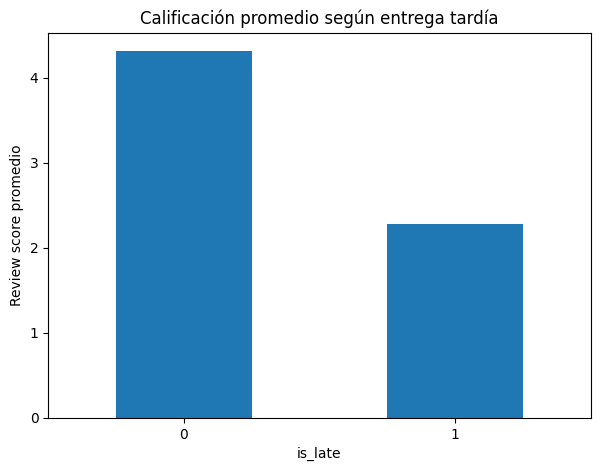

In [36]:
late_summary = analysis_df.groupby("is_late").agg(
    review_score_promedio=("review_score", "mean"),
    porcentaje_reseña_negativa=("negative_review", lambda s: s.mean() * 100),
    n_ordenes=("order_id", "count")
)

display(late_summary.round(2))

plt.figure(figsize=(7,5))
late_summary["review_score_promedio"].plot(kind="bar")
plt.title("Calificación promedio según entrega tardía")
plt.xlabel("is_late")
plt.ylabel("Review score promedio")
plt.xticks(rotation=0)
plt.show()

,porcentaje_reseña_negativa,review_score_promedio,n_ordenes
delivery_quintile,,,
"(-0.001, 6.0]",6.55,4.45,24917
"(6.0, 8.0]",7.62,4.39,13831
"(8.0, 12.0]",8.63,4.32,20598
"(12.0, 17.0]",10.56,4.20,15774
"(17.0, 208.0]",29.91,3.43,17476


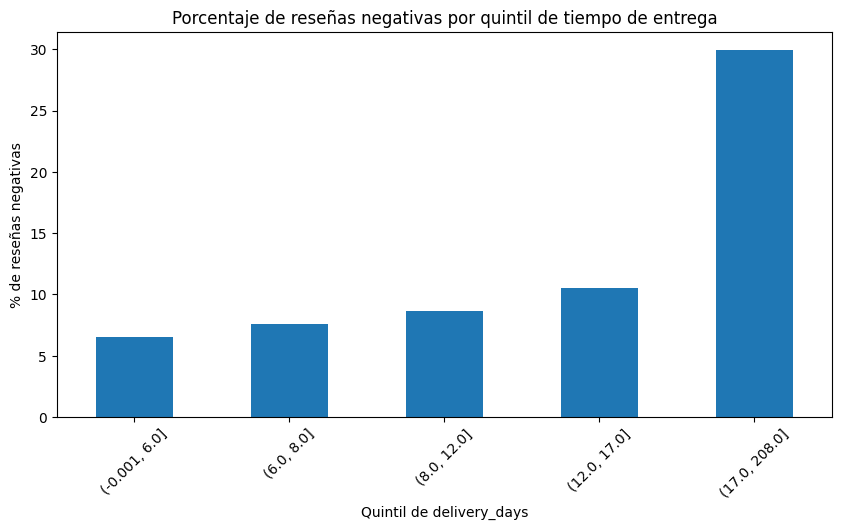

In [37]:
analysis_df["delivery_quintile"] = pd.qcut(
    analysis_df["delivery_days"],
    q=5,
    duplicates="drop"
)

delivery_quint_summary = analysis_df.groupby("delivery_quintile").agg(
    porcentaje_reseña_negativa=("negative_review", lambda s: s.mean() * 100),
    review_score_promedio=("review_score", "mean"),
    n_ordenes=("order_id", "count")
)

display(delivery_quint_summary.round(2))

plt.figure(figsize=(10,5))
delivery_quint_summary["porcentaje_reseña_negativa"].plot(kind="bar")
plt.title("Porcentaje de reseñas negativas por quintil de tiempo de entrega")
plt.xlabel("Quintil de delivery_days")
plt.ylabel("% de reseñas negativas")
plt.xticks(rotation=45)
plt.show()

### Interpretación

Aquí aparece la señal exploratoria más fuerte de toda la sección. Las órdenes **no tardías** tienen una calificación promedio de **4.31** y una tasa de reseñas negativas de **8.66%**, mientras que las órdenes **tardías** caen a una calificación promedio de **2.27** y elevan las reseñas negativas a **62.29%**. Además, al comparar quintiles de tiempo de entrega, el grupo con mayores tiempos concentra casi **29.91%** de reseñas negativas, frente a solo **6.55%** en el quintil más rápido. Esto sugiere que el tiempo de entrega, y especialmente la tardanza, es un candidato muy fuerte para explicar la satisfacción del cliente.

### 4.4 Distancia geográfica y satisfacción

La segunda dimensión central del proyecto es la distancia geográfica entre el vendedor y el cliente. Gracias al nuevo dataset analítico, esta variable ya no es una proxy indirecta, sino una distancia real calculada con coordenadas válidas de origen y destino. El objetivo ahora es evaluar si los pedidos más lejanos tienden a asociarse con peores tiempos de entrega y con menor satisfacción.

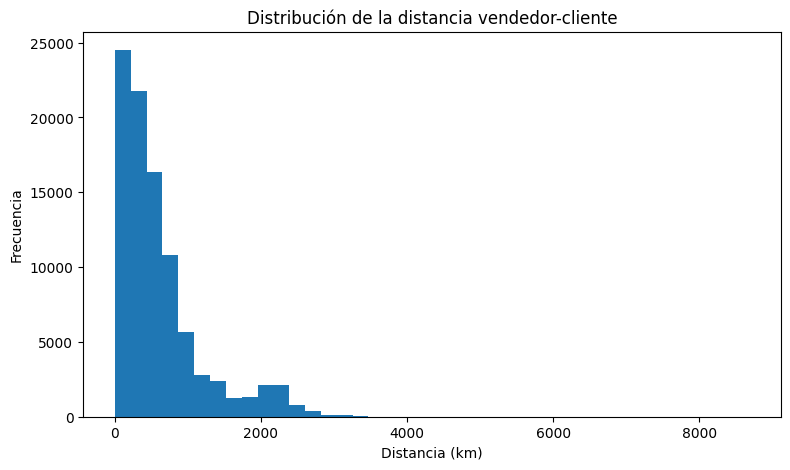

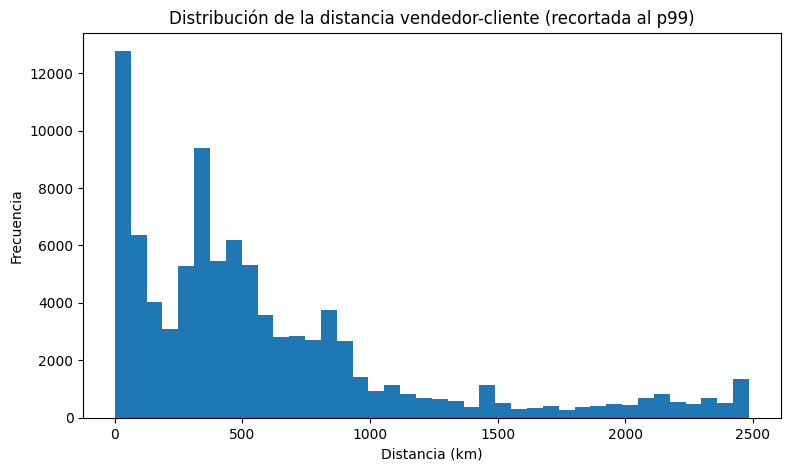

In [38]:
plt.figure(figsize=(9,5))
plt.hist(analysis_df["distance_km"], bins=40)
plt.title("Distribución de la distancia vendedor-cliente")
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9,5))
plt.hist(analysis_df["distance_km_capped"], bins=40)
plt.title("Distribución de la distancia vendedor-cliente (recortada al p99)")
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.show()

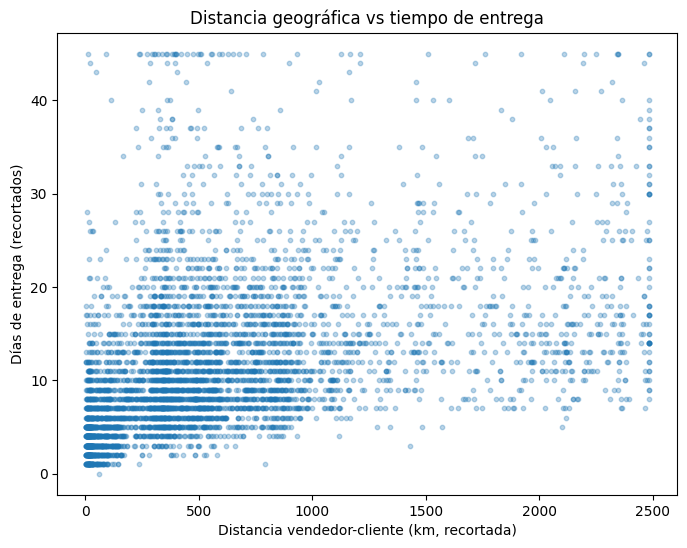

In [39]:
sample_df = analysis_df.sample(min(5000, len(analysis_df)), random_state=42)

plt.figure(figsize=(8,6))
plt.scatter(
    sample_df["distance_km_capped"],
    sample_df["delivery_days_capped"],
    alpha=0.3,
    s=10
)
plt.title("Distancia geográfica vs tiempo de entrega")
plt.xlabel("Distancia vendedor-cliente (km, recortada)")
plt.ylabel("Días de entrega (recortados)")
plt.show()

,distancia_promedio_km,tiempo_entrega_promedio,n_ordenes
satisfaction_level,,,
Negativa,678.98,20.33,11354
Neutral,637.21,13.90,7598
Positiva,586.19,10.63,73644


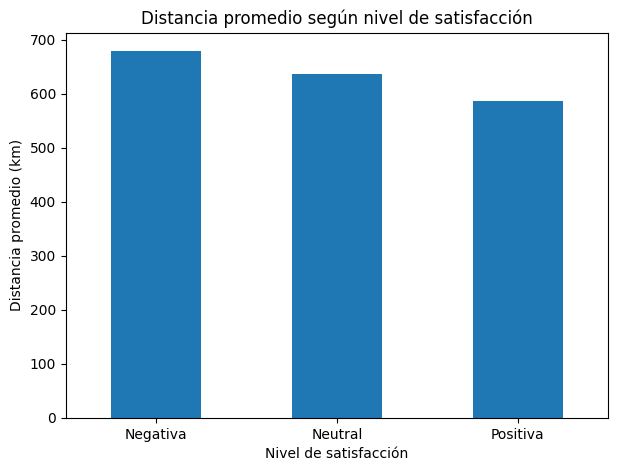

In [40]:
distance_by_sat = analysis_df.groupby("satisfaction_level").agg(
    distancia_promedio_km=("distance_km", "mean"),
    tiempo_entrega_promedio=("delivery_days", "mean"),
    n_ordenes=("order_id", "count")
)

display(distance_by_sat.round(2))

plt.figure(figsize=(7,5))
distance_by_sat["distancia_promedio_km"].plot(kind="bar")
plt.title("Distancia promedio según nivel de satisfacción")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Distancia promedio (km)")
plt.xticks(rotation=0)
plt.show()

,porcentaje_reseña_negativa,review_score_promedio,n_ordenes
distance_quintile,,,
"(-0.001, 116.441]",9.80,4.30,18520
"(116.441, 348.0]",11.74,4.21,18519
"(348.0, 530.697]",12.26,4.18,18519
"(530.697, 877.383]",12.90,4.13,18519
"(877.383, 2484.972]",14.61,4.06,18519


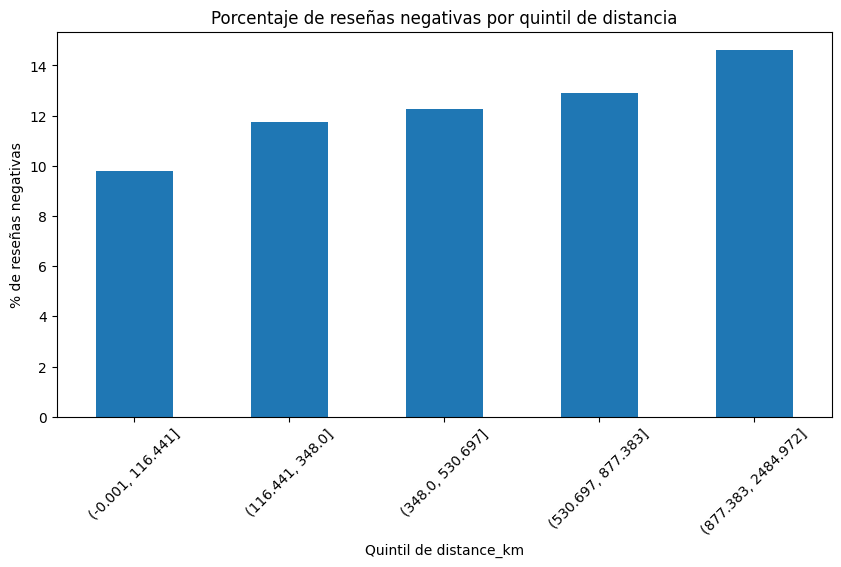

In [41]:
analysis_df["distance_quintile"] = pd.qcut(
    analysis_df["distance_km_capped"],
    q=5,
    duplicates="drop"
)

distance_quint_summary = analysis_df.groupby("distance_quintile").agg(
    porcentaje_reseña_negativa=("negative_review", lambda s: s.mean() * 100),
    review_score_promedio=("review_score", "mean"),
    n_ordenes=("order_id", "count")
)

display(distance_quint_summary.round(2))

plt.figure(figsize=(10,5))
distance_quint_summary["porcentaje_reseña_negativa"].plot(kind="bar")
plt.title("Porcentaje de reseñas negativas por quintil de distancia")
plt.xlabel("Quintil de distance_km")
plt.ylabel("% de reseñas negativas")
plt.xticks(rotation=45)
plt.show()

### Interpretación

La distancia vendedor-cliente también muestra una distribución asimétrica, con una mediana cercana a **434 km** y una cola larga que llega hasta casi **8,678 km**. En términos de satisfacción, las órdenes negativas presentan una distancia promedio de **678.98 km**, frente a **586.19 km** en las positivas. Además, la tasa de reseñas negativas aumenta de **9.80%** en el quintil más cercano a **14.61%** en el más lejano. Esto sugiere que la distancia sí influye en la experiencia del cliente, aunque con una intensidad moderada y mucho menor que la observada para el tiempo de entrega.

### 4.5 Tipo de producto y satisfacción

El tercer factor central del proyecto es el tipo de producto. Como esta variable es categórica, su análisis requiere una estrategia distinta a la del tiempo y la distancia. Primero se observan las categorías más frecuentes del dataset final y luego se comparan niveles de satisfacción entre categorías con suficiente volumen, evitando interpretar grupos demasiado pequeños o inestables.

product_category_name
cama_mesa_banho           8772
beleza_saude              8477
esporte_lazer             7351
informatica_acessorios    6367
moveis_decoracao          5974
utilidades_domesticas     5536
relogios_presentes        5358
telefonia                 3994
automotivo                3724
brinquedos                3676
Name: count, dtype: int64

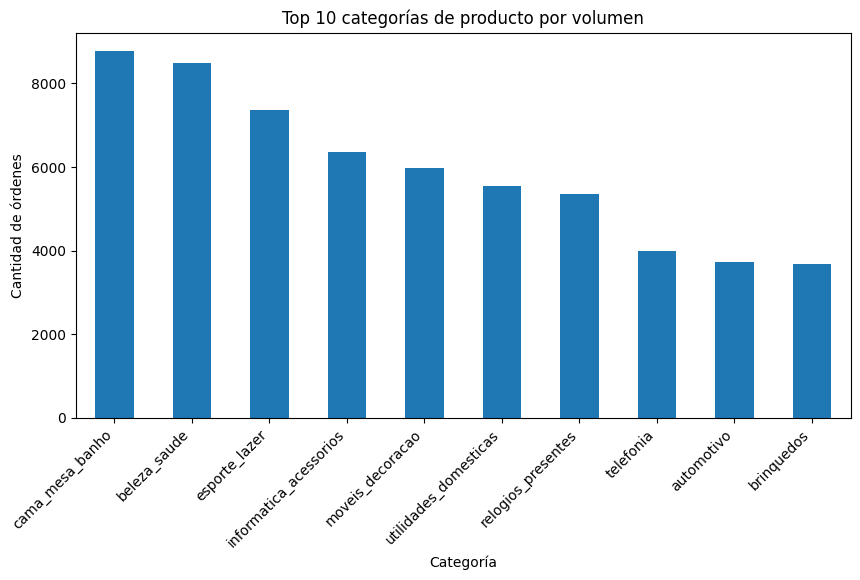

In [42]:
top_categories = analysis_df["product_category_name"].value_counts().head(10)

display(top_categories)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 10 categorías de producto por volumen")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de órdenes")
plt.xticks(rotation=45, ha="right")
plt.show()

In [43]:
min_orders = 500

category_stats = (
    analysis_df.groupby("product_category_name")
    .agg(
        n_ordenes=("order_id", "count"),
        review_score_promedio=("review_score", "mean"),
        porcentaje_reseña_negativa=("negative_review", lambda s: s.mean() * 100),
        delivery_days_promedio=("delivery_days", "mean"),
        distance_km_promedio=("distance_km", "mean")
    )
    .query("n_ordenes >= @min_orders")
    .sort_values("n_ordenes", ascending=False)
)

top10_category_stats = category_stats.head(10)
display(top10_category_stats.round(2))

,n_ordenes,review_score_promedio,porcentaje_reseña_negativa,delivery_days_promedio,distance_km_promedio
product_category_name,,,,,
cama_mesa_banho,8772,4.05,14.76,12.59,512.88
beleza_saude,8477,4.24,11.18,11.62,681.26
esporte_lazer,7351,4.25,10.76,11.81,597.83
informatica_acessorios,6367,4.10,13.93,12.74,677.98
moveis_decoracao,5974,4.11,14.11,12.70,566.46
utilidades_domesticas,5536,4.23,11.07,10.67,494.23
relogios_presentes,5358,4.14,13.10,12.33,646.22
telefonia,3994,4.06,13.82,12.52,696.57
automotivo,3724,4.17,12.46,11.82,620.17


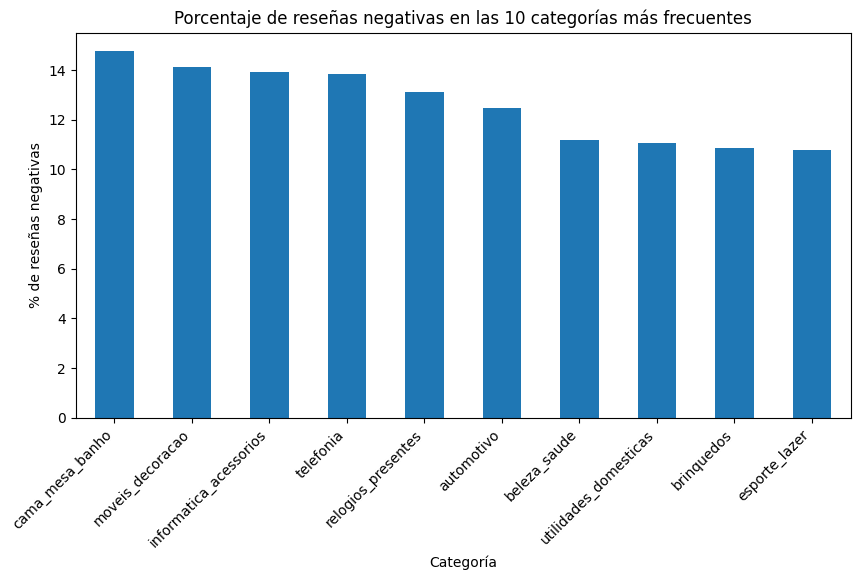

In [44]:
plt.figure(figsize=(10,5))
top10_category_stats["porcentaje_reseña_negativa"].sort_values(ascending=False).plot(kind="bar")
plt.title("Porcentaje de reseñas negativas en las 10 categorías más frecuentes")
plt.xlabel("Categoría")
plt.ylabel("% de reseñas negativas")
plt.xticks(rotation=45, ha="right")
plt.show()

In [45]:
worst_categories = category_stats.sort_values(
    ["porcentaje_reseña_negativa", "n_ordenes"],
    ascending=[False, False]
).head(10)

display(worst_categories.round(2))

,n_ordenes,review_score_promedio,porcentaje_reseña_negativa,delivery_days_promedio,distance_km_promedio
product_category_name,,,,,
moveis_escritorio,1221,3.66,21.62,20.20,564.77
cama_mesa_banho,8772,4.05,14.76,12.59,512.88
moveis_decoracao,5974,4.11,14.11,12.70,566.46
informatica_acessorios,6367,4.10,13.93,12.74,677.98
telefonia,3994,4.06,13.82,12.52,696.57
relogios_presentes,5358,4.14,13.10,12.33,646.22
bebes,2672,4.15,12.95,12.22,607.57
eletronicos,2381,4.14,12.73,12.45,625.80
automotivo,3724,4.17,12.46,11.82,620.17


### Interpretación

El tipo de producto sí parece introducir diferencias en la satisfacción, pero de magnitud intermedia. Entre las 10 categorías más frecuentes, las peores tasas de reseñas negativas se observan en **cama_mesa_banho (14.76%)**, **moveis_decoracao (14.11%)** e **informatica_acessorios (13.93%)**, mientras que categorías como **brinquedos (10.85%)** y **esporte_lazer (10.76%)** muestran mejores resultados. Además, entre las categorías con al menos 500 órdenes, **moveis_escritorio** aparece como el caso más crítico, con **21.62%** de reseñas negativas y un tiempo de entrega promedio de **20.20 días**. Esto sugiere que el tipo de producto sí importa, pero probablemente en parte porque ciertas categorías están asociadas con procesos logísticos más complejos o lentos.

### 4.6 Comparación preliminar entre tiempo, distancia y tipo de producto

Después de explorar cada dimensión por separado, conviene compararlas de manera sintética para identificar cuál parece tener mayor capacidad explicativa sobre la satisfacción del cliente. Esta comparación no reemplaza el modelado posterior, pero ayuda a establecer una jerarquía preliminar entre los factores analizados.

,review_score,negative_review,delivery_days,delay_days,distance_km,freight_ratio,total_price,total_weight_kg
review_score,1.000,-0.867,-0.346,-0.280,-0.062,-0.025,-0.030,-0.052
negative_review,-0.867,1.000,0.325,0.271,0.049,0.017,0.039,0.049
delivery_days,-0.346,0.325,1.000,0.601,0.396,0.081,0.057,0.075
delay_days,-0.280,0.271,0.601,1.000,-0.076,-0.032,-0.011,0.006
distance_km,-0.062,0.049,0.396,-0.076,1.000,0.200,0.078,-0.010
freight_ratio,-0.025,0.017,0.081,-0.032,0.200,1.000,-0.300,-0.087
total_price,-0.030,0.039,0.057,-0.011,0.078,-0.300,1.000,0.352
total_weight_kg,-0.052,0.049,0.075,0.006,-0.010,-0.087,0.352,1.000


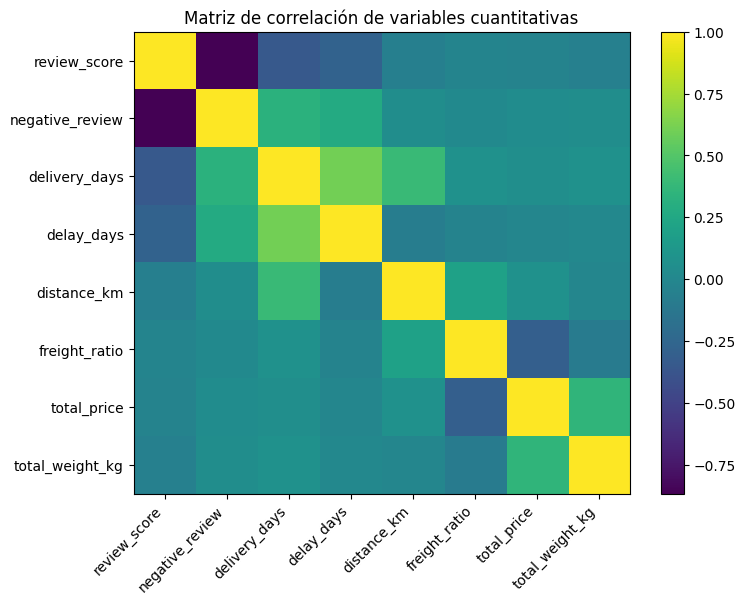

In [47]:
corr_matrix = analysis_df[
    [
        "review_score",
        "negative_review",
        "delivery_days",
        "delay_days",
        "distance_km",
        "freight_ratio",
        "total_price",
        "total_weight_kg"
    ]
].corr()

display(corr_matrix.round(3))

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Matriz de correlación de variables cuantitativas")
plt.show()

In [48]:
effect_summary = pd.DataFrame({
    "Factor": [
        "Tiempo de entrega (quintil más lento vs más rápido)",
        "Tardanza (entrega tardía vs no tardía)",
        "Distancia (quintil más lejano vs más cercano)",
        "Tipo de producto (brecha en top 10 categorías más frecuentes)"
    ],
    "Indicador comparado": [
        "Brecha en % de reseñas negativas",
        "Brecha en % de reseñas negativas",
        "Brecha en % de reseñas negativas",
        "Brecha en % de reseñas negativas"
    ],
    "Valor": [
        round(
            delivery_quint_summary["porcentaje_reseña_negativa"].iloc[-1]
            - delivery_quint_summary["porcentaje_reseña_negativa"].iloc[0], 2
        ),
        round(
            late_summary["porcentaje_reseña_negativa"].loc[1]
            - late_summary["porcentaje_reseña_negativa"].loc[0], 2
        ),
        round(
            distance_quint_summary["porcentaje_reseña_negativa"].iloc[-1]
            - distance_quint_summary["porcentaje_reseña_negativa"].iloc[0], 2
        ),
        round(
            top10_category_stats["porcentaje_reseña_negativa"].max()
            - top10_category_stats["porcentaje_reseña_negativa"].min(), 2
        )
    ]
})

display(effect_summary)

,Factor,Indicador comparado,Valor
0,Tiempo de entrega (quintil más lento vs más rá...,Brecha en % de reseñas negativas,23.36
1,Tardanza (entrega tardía vs no tardía),Brecha en % de reseñas negativas,53.63
2,Distancia (quintil más lejano vs más cercano),Brecha en % de reseñas negativas,4.81
3,Tipo de producto (brecha en top 10 categorías ...,Brecha en % de reseñas negativas,4.00


### Interpretación

La comparación preliminar es bastante clara. La mayor brecha aparece en la **tardanza**, donde la diferencia entre órdenes tardías y no tardías alcanza aproximadamente **53.63 puntos porcentuales** en reseñas negativas. Luego aparece el **tiempo de entrega**, cuya diferencia entre el quintil más lento y el más rápido es de **23.36 puntos**. Mucho más abajo quedan la **distancia**, con una brecha de **4.81 puntos**, y el **tipo de producto**, cuya diferencia entre las categorías más frecuentes ronda los **4 puntos**. En conjunto, esto sugiere que el factor dominante en la satisfacción del cliente es el desempeño logístico temporal, mientras que la distancia y el tipo de producto actúan como factores secundarios o complementarios.

## 4.7 Hallazgos preliminares

El análisis exploratorio del dataset final sugiere que la satisfacción del cliente en Olist sigue concentrándose en niveles altos, pero conserva un grupo suficientemente grande de experiencias negativas como para justificar un estudio detallado de sus determinantes. Entre los tres factores analizados, el **tiempo de entrega** emerge como la señal más fuerte: las órdenes tardías presentan un deterioro drástico en la calificación promedio y concentran una proporción muy superior de reseñas negativas. La **distancia geográfica** también parece influir, pero de manera más moderada, probablemente porque su efecto se transmite en parte a través del aumento en el tiempo de entrega. Finalmente, el **tipo de producto** introduce diferencias relevantes entre categorías, especialmente en productos asociados con operaciones logísticas más complejas, aunque su capacidad explicativa preliminar parece menor que la del componente temporal.

En esta etapa, la evidencia exploratoria sugiere una jerarquía inicial entre los factores: primero el tiempo de entrega, luego la distancia y finalmente el tipo de producto. La siguiente sección formalizará esta intuición mediante el ajuste por máxima verosimilitud sobre `delivery_days`, que será la variable principal del análisis de distribución.

## 5. Estimación por máxima verosimilitud (MLE)

En esta sección se modela formalmente la variable `delivery_days` mediante estimación por máxima verosimilitud. El propósito es identificar qué distribución describe mejor el comportamiento del tiempo de entrega en Olist y comparar distintos modelos candidatos usando criterios de información. Esta etapa es importante porque permite pasar de una observación descriptiva del fenómeno a una comparación cuantitativa entre modelos, apoyando una conclusión estadísticamente sólida sobre la forma de la variable logística principal del análisis.

### 5.1 Variable seleccionada y decisión metodológica

La variable elegida para el análisis por máxima verosimilitud es `delivery_days`, ya que representa el tiempo real transcurrido entre la compra y la entrega al cliente. Esta variable es adecuada porque es continua, no negativa y mostró en el análisis exploratorio una fuerte asimetría a la derecha.

Dado que `delivery_days` contiene algunos valores iguales a cero, y que distribuciones como la Log-Normal y la Gamma requieren valores estrictamente positivos cuando se fija `loc = 0`, el ajuste se realizará sobre la submuestra `delivery_days > 0`. Esta decisión garantiza una comparación justa entre modelos, ya que todos serán estimados sobre exactamente la misma muestra.

In [49]:
# ============================================
# 5. ESTIMACIÓN POR MÁXIMA VEROSIMILITUD (MLE)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Serie original y serie positiva para ajuste
x_all = analysis_df["delivery_days"].dropna().astype(float)
x_pos = x_all[x_all > 0].copy()

mle_input_summary = pd.DataFrame({
    "Serie": ["delivery_days completo", "delivery_days > 0"],
    "n": [len(x_all), len(x_pos)],
    "mínimo": [x_all.min(), x_pos.min()],
    "mediana": [x_all.median(), x_pos.median()],
    "media": [x_all.mean(), x_pos.mean()],
    "máximo": [x_all.max(), x_pos.max()]
})

display(mle_input_summary)
print("Número de observaciones excluidas por ser 0 días:", (x_all == 0).sum())

,Serie,n,mínimo,mediana,media,máximo
0,delivery_days completo,92596,0.0,10.0,12.087390,208.0
1,delivery_days > 0,92583,1.0,10.0,12.089088,208.0


Número de observaciones excluidas por ser 0 días: 13


### 5.2 Visualización inicial

Antes de ajustar modelos, se representa gráficamente la variable sobre la muestra positiva. Esto permite confirmar visualmente la asimetría observada en el análisis exploratorio y anticipar qué distribuciones podrían describir mejor el comportamiento del tiempo de entrega.

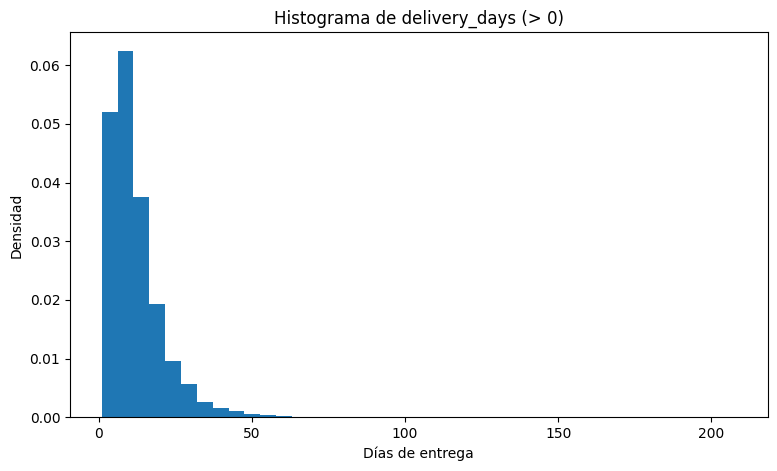

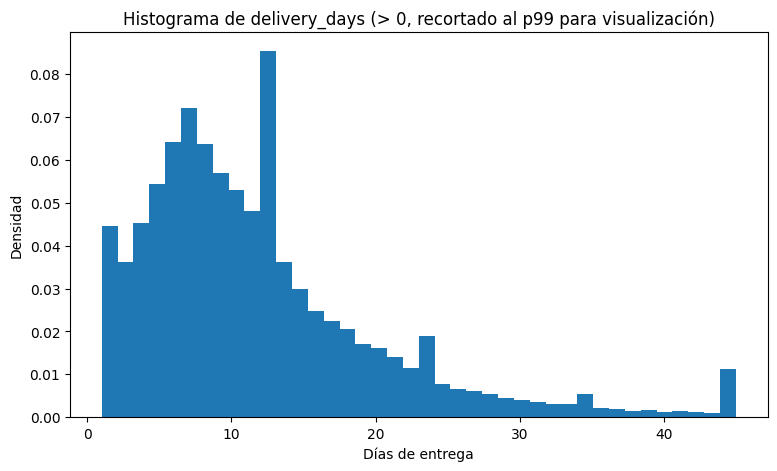

In [50]:
plt.figure(figsize=(9,5))
plt.hist(x_pos, bins=40, density=True)
plt.title("Histograma de delivery_days (> 0)")
plt.xlabel("Días de entrega")
plt.ylabel("Densidad")
plt.show()

plt.figure(figsize=(9,5))
plt.hist(x_pos.clip(upper=x_pos.quantile(0.99)), bins=40, density=True)
plt.title("Histograma de delivery_days (> 0, recortado al p99 para visualización)")
plt.xlabel("Días de entrega")
plt.ylabel("Densidad")
plt.show()

In [51]:
display(x_pos.describe())
display(x_pos.quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]))

count    92583.000000
mean        12.089088
std          9.493534
min          1.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

0.00      1.0
0.01      1.0
0.05      3.0
0.25      6.0
0.50     10.0
0.75     15.0
0.95     29.0
0.99     45.0
1.00    208.0
Name: delivery_days, dtype: float64

### Interpretación esperada

En esta etapa debería observarse una distribución positiva y claramente asimétrica, con una concentración importante en tiempos de entrega relativamente bajos y una cola derecha asociada a demoras más extremas. Esa forma hace razonable comparar una distribución simétrica como la Normal con alternativas positivas y sesgadas como la Log-Normal y la Gamma.

### 5.3 Distribuciones candidatas

Se compararán cuatro distribuciones candidatas:

- **Normal**, como referencia base.
- **Log-Normal**, adecuada para variables estrictamente positivas con cola derecha.
- **Gamma**, apropiada para duraciones y tiempos positivos asimétricos.
- **Exponencial**, como modelo simple de duración positiva que sirve como línea base adicional.

Para hacer la comparación correctamente, se ajustarán las cuatro distribuciones sobre la misma muestra positiva (`x_pos`). Además, cuando se fije `loc = 0`, el número de parámetros libres se ajustará correctamente al calcular AIC y BIC.

#### 5.4 Ajuste de distribuciones por MLE

In [52]:
# Convertir a numpy para mayor estabilidad
x = x_pos.values
n = len(x)

fit_results = []

# 1. Normal (2 parámetros libres: mu, sigma)
norm_params = stats.norm.fit(x)
norm_loglik = np.sum(stats.norm.logpdf(x, *norm_params))
fit_results.append({
    "Distribución": "Normal",
    "LogLik": norm_loglik,
    "k": 2,
    "params": norm_params
})

# 2. Log-Normal con loc fijado en 0
# parámetros libres reales: shape y scale
lognorm_params = stats.lognorm.fit(x, floc=0)
lognorm_loglik = np.sum(stats.lognorm.logpdf(x, *lognorm_params))
fit_results.append({
    "Distribución": "Log-Normal",
    "LogLik": lognorm_loglik,
    "k": 2,
    "params": lognorm_params
})

# 3. Gamma con loc fijado en 0
# parámetros libres reales: shape y scale
gamma_params = stats.gamma.fit(x, floc=0)
gamma_loglik = np.sum(stats.gamma.logpdf(x, *gamma_params))
fit_results.append({
    "Distribución": "Gamma",
    "LogLik": gamma_loglik,
    "k": 2,
    "params": gamma_params
})

# 4. Exponencial con loc fijado en 0
# parámetro libre real: scale
expon_params = stats.expon.fit(x, floc=0)
expon_loglik = np.sum(stats.expon.logpdf(x, *expon_params))
fit_results.append({
    "Distribución": "Exponencial",
    "LogLik": expon_loglik,
    "k": 1,
    "params": expon_params
})

for result in fit_results:
    print(result["Distribución"], "-> params:", result["params"], "| LogLik:", round(result["LogLik"], 2))

Normal -> params: (np.float64(12.089087629478414), np.float64(9.493482674561708)) | LogLik: -339737.4
Log-Normal -> params: (np.float64(0.7318685175893399), 0, np.float64(9.426555884187465)) | LogLik: -310182.21
Gamma -> params: (2.1617890919961846, 0, np.float64(5.592167928979332)) | LogLik: -310438.46
Exponencial -> params: (0.0, 12.089087629478414) | LogLik: -323327.91


### 5.5 Comparación de modelos con AIC y BIC

El AIC y el BIC permiten comparar modelos penalizando la complejidad. En ambos casos, valores más bajos indican un mejor equilibrio entre ajuste y parsimonia. La comparación se hace sobre la misma muestra, por lo que el resultado es metodológicamente consistente.

In [53]:
def calc_aic(loglik, k):
    return 2 * k - 2 * loglik

def calc_bic(loglik, k, n):
    return np.log(n) * k - 2 * loglik

results_mle = pd.DataFrame({
    "Distribución": [r["Distribución"] for r in fit_results],
    "LogLik": [r["LogLik"] for r in fit_results],
    "Parámetros libres (k)": [r["k"] for r in fit_results],
    "AIC": [calc_aic(r["LogLik"], r["k"]) for r in fit_results],
    "BIC": [calc_bic(r["LogLik"], r["k"], n) for r in fit_results]
})

results_mle = results_mle.sort_values("AIC").reset_index(drop=True)
results_mle["ΔAIC"] = (results_mle["AIC"] - results_mle["AIC"].min()).round(4)
results_mle["ΔBIC"] = (results_mle["BIC"] - results_mle["BIC"].min()).round(4)

display(results_mle)

,Distribución,LogLik,Parámetros libres (k),AIC,BIC,ΔAIC,ΔBIC
0,Log-Normal,-310182.207306,2,620368.414612,620387.286333,0.0000,0.0000
1,Gamma,-310438.460698,2,620880.921396,620899.793118,512.5068,512.5068
2,Exponencial,-323327.906878,1,646657.813755,646667.249616,26289.3991,26279.9633
3,Normal,-339737.397904,2,679478.795807,679497.667529,59110.3812,59110.3812


#### 5.6 Identificación del modelo ganador

In [54]:
best_model = results_mle.loc[0, "Distribución"]
second_model = results_mle.loc[1, "Distribución"]
aic_winner = results_mle.loc[0, "AIC"]
aic_second = results_mle.loc[1, "AIC"]
bic_winner = results_mle.loc[0, "BIC"]
bic_second = results_mle.loc[1, "BIC"]

print("Modelo ganador por AIC:", best_model)
print("Segundo mejor modelo por AIC:", second_model)
print("AIC ganador:", round(aic_winner, 4))
print("AIC segundo:", round(aic_second, 4))
print("Diferencia de AIC:", round(aic_second - aic_winner, 4))

print("\nBIC ganador:", round(bic_winner, 4))
print("BIC segundo:", round(bic_second, 4))
print("Diferencia de BIC:", round(bic_second - bic_winner, 4))

Modelo ganador por AIC: Log-Normal
Segundo mejor modelo por AIC: Gamma
AIC ganador: 620368.4146
AIC segundo: 620880.9214
Diferencia de AIC: 512.5068

BIC ganador: 620387.2863
BIC segundo: 620899.7931
Diferencia de BIC: 512.5068


### Interpretación 

Si la diferencia de AIC entre el mejor modelo y el segundo es claramente mayor que 2, puede decirse que existe evidencia favorable al modelo ganador. Si además ese mismo modelo presenta el menor BIC, la conclusión se fortalece. En una variable como `delivery_days`, lo más plausible es que la Normal quede rezagada frente a modelos positivos y asimétricos.

### 5.7 Visualización del ajuste

Además de AIC y BIC, conviene observar visualmente cómo se comportan las densidades ajustadas sobre el histograma. Para que la comparación sea más legible, se grafica sobre un rango hasta el percentil 99.5 de la muestra positiva, manteniendo el ajuste estimado sobre todos los datos positivos.

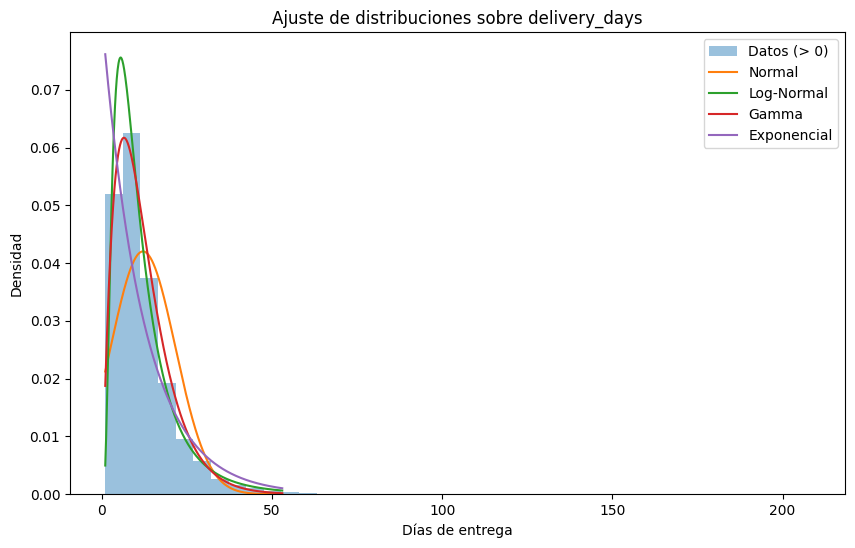

In [55]:
x_grid = np.linspace(x.min(), np.quantile(x, 0.995), 600)

norm_pdf = stats.norm.pdf(x_grid, *norm_params)
lognorm_pdf = stats.lognorm.pdf(x_grid, *lognorm_params)
gamma_pdf = stats.gamma.pdf(x_grid, *gamma_params)
expon_pdf = stats.expon.pdf(x_grid, *expon_params)

plt.figure(figsize=(10,6))
plt.hist(x, bins=40, density=True, alpha=0.45, label="Datos (> 0)")
plt.plot(x_grid, norm_pdf, label="Normal")
plt.plot(x_grid, lognorm_pdf, label="Log-Normal")
plt.plot(x_grid, gamma_pdf, label="Gamma")
plt.plot(x_grid, expon_pdf, label="Exponencial")
plt.title("Ajuste de distribuciones sobre delivery_days")
plt.xlabel("Días de entrega")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### 5.8 Parámetros estimados del modelo seleccionado

Una vez identificado el mejor modelo, se reportan sus parámetros estimados. Esta parte es especialmente importante para la defensa oral, porque el profesor puede pedir no solo el modelo ganador, sino también los valores concretos de los parámetros y su interpretación.

In [56]:
if best_model == "Normal":
    mu, sigma = norm_params
    print("Modelo ganador: Normal")
    print(f"mu = {mu:.4f}")
    print(f"sigma = {sigma:.4f}")
    print(f"Interpretación rápida: el tiempo de entrega se concentra alrededor de {mu:.2f} días con una dispersión de {sigma:.2f} días.")

elif best_model == "Log-Normal":
    shape, loc, scale = lognorm_params
    mu_log = np.log(scale)
    sigma_log = shape
    median_implied = scale  # con loc=0, la mediana es scale
    print("Modelo ganador: Log-Normal")
    print(f"shape (sigma_log) = {sigma_log:.4f}")
    print(f"loc = {loc:.4f}")
    print(f"scale = {scale:.4f}")
    print(f"mu_log = {mu_log:.4f}")
    print(f"Mediana implícita del modelo = {median_implied:.2f} días")
    print("Interpretación rápida: la mayoría de entregas se concentra en pocos días, pero existe una cola derecha marcada de pedidos mucho más lentos.")

elif best_model == "Gamma":
    shape, loc, scale = gamma_params
    mean_implied = shape * scale
    print("Modelo ganador: Gamma")
    print(f"shape (alpha) = {shape:.4f}")
    print(f"loc = {loc:.4f}")
    print(f"scale (theta) = {scale:.4f}")
    print(f"Media implícita del modelo = {mean_implied:.2f} días")
    print("Interpretación rápida: el tiempo de entrega es positivo y asimétrico, con concentración en valores relativamente bajos y una cola de entregas más largas.")

elif best_model == "Exponencial":
    loc, scale = expon_params
    print("Modelo ganador: Exponencial")
    print(f"loc = {loc:.4f}")
    print(f"scale = {scale:.4f}")
    print(f"Tasa implícita lambda = {1/scale:.4f}")
    print("Interpretación rápida: el tiempo de entrega seguiría una estructura de decaimiento simple, aunque esto suele ser demasiado restrictivo para datos logísticos reales.")

Modelo ganador: Log-Normal
shape (sigma_log) = 0.7319
loc = 0.0000
scale = 9.4266
mu_log = 2.2435
Mediana implícita del modelo = 9.43 días
Interpretación rápida: la mayoría de entregas se concentra en pocos días, pero existe una cola derecha marcada de pedidos mucho más lentos.


### 5.9 Nota conceptual para la defensa

Dependiendo del modelo ganador, cambia la forma de resumir la información relevante del conjunto de datos:

- Si gana la **Normal**, los parámetros clave son la media y la desviación estándar.
- Si gana la **Log-Normal**, la información relevante está en la media y la varianza del logaritmo del tiempo de entrega.
- Si gana la **Gamma**, la estimación se apoya en la estructura positiva y asimétrica de la variable, y los parámetros capturan forma y escala.


### 5.10 Texto de interpretación final

La distribución que mejor ajustó la variable `delivery_days` fue la **Log-Normal**, con **AIC = 620368.4146** y **BIC = 620387.2863**, superando ampliamente a la distribución Gamma, que fue el segundo mejor modelo, por **512.5068 puntos** en ambos criterios. Este resultado confirma que el tiempo de entrega en Olist no es simétrico, sino que presenta una fuerte asimetría a la derecha: la mayoría de pedidos se entrega en pocos días, pero existe una minoría con demoras mucho mayores.

Los parámetros estimados del modelo ganador fueron **shape = 0.7319**, **loc = 0** y **scale = 9.4266**, lo que implica una mediana teórica cercana a **9.43 días**, muy consistente con la mediana empírica observada de **10 días**. En términos de negocio, esto sugiere que la logística de Olist funciona bien para la mayoría de pedidos, pero una fracción pequeña de entregas lentas genera una cola de demoras que puede afectar de manera importante la satisfacción del cliente.

## 6. Inferencia bayesiana

En esta sección se modela la probabilidad de insatisfacción del cliente mediante inferencia bayesiana. El fenómeno de interés será la probabilidad de recibir una **reseña negativa**, definida como `review_score <= 2`. Para construir el análisis se utilizará un modelo Beta-Binomial, donde la distribución Beta representará la incertidumbre sobre la probabilidad de insatisfacción y la distribución Binomial modelará el número de reseñas negativas observadas en un grupo de órdenes.

La estrategia será la siguiente: primero se construirá un **prior histórico** usando órdenes realizadas antes de 2018; después se actualizará ese prior con las órdenes de 2018 para obtener el **posterior**. Finalmente, se compararán los resultados entre grupos alineados con la pregunta del proyecto: tiempo de entrega, distancia geográfica y tipo de producto.

### 6.1 Fenómeno modelado y división temporal

El fenómeno a modelar es la probabilidad de que una orden reciba una reseña negativa. Para construir un prior histórico y un posterior actualizado, se separa el dataset analítico en dos periodos: un bloque histórico con órdenes anteriores a 2018 y un bloque actual con órdenes realizadas en 2018. Esta división permite que el prior represente información previa y que el posterior incorpore evidencia nueva.

In [57]:
from scipy.stats import beta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bayes_df = analysis_df.copy()

# Seguridad por si la fecha no quedó en datetime en alguna sesión
if not pd.api.types.is_datetime64_any_dtype(bayes_df["order_purchase_timestamp"]):
    bayes_df["order_purchase_timestamp"] = pd.to_datetime(
        bayes_df["order_purchase_timestamp"], errors="coerce"
    )

bayes_df["purchase_year"] = bayes_df["order_purchase_timestamp"].dt.year

historical_df = bayes_df[bayes_df["purchase_year"] < 2018].copy()
current_df = bayes_df[bayes_df["purchase_year"] == 2018].copy()

time_split_summary = pd.DataFrame({
    "Periodo": ["Histórico (< 2018)", "Actual (2018)"],
    "Órdenes": [len(historical_df), len(current_df)],
    "Reseñas negativas": [
        int(historical_df["negative_review"].sum()),
        int(current_df["negative_review"].sum())
    ],
    "Tasa de reseña negativa": [
        historical_df["negative_review"].mean(),
        current_df["negative_review"].mean()
    ]
})

time_split_summary["Tasa de reseña negativa"] = (
    time_split_summary["Tasa de reseña negativa"] * 100
).round(2)

display(time_split_summary)

,Periodo,Órdenes,Reseñas negativas,Tasa de reseña negativa
0,Histórico (< 2018),41818,4887,11.69
1,Actual (2018),50778,6467,12.74


### Interpretación

La división temporal deja una base histórica de **41,818 órdenes** y una base actual de **50,778 órdenes**. La tasa de reseñas negativas aumenta ligeramente de **11.69%** en el periodo histórico a **12.74%** en 2018. Esto sugiere que la insatisfacción sigue siendo relativamente minoritaria dentro del total de órdenes, pero también indica que en el periodo más reciente el riesgo de reseña negativa fue algo mayor. Esa diferencia justifica construir un prior histórico y actualizarlo con evidencia nueva en lugar de tratar toda la base como un solo bloque homogéneo.

### 6.2 Construcción del prior histórico

Para modelar la probabilidad de reseña negativa se usa una distribución Beta como prior. La media del prior se calibra con la tasa histórica observada, y su fuerza se fija mediante un número moderado de pseudo-observaciones. En este caso se utilizarán **100 pseudo-observaciones**, una cantidad suficientemente informativa para reflejar el comportamiento histórico de Olist sin llegar a dominar por completo la evidencia nueva de 2018.

In [58]:
historical_rate = historical_df["negative_review"].mean()

prior_strength = 100  # pseudo-observaciones moderadas
alpha_prior = 1 + prior_strength * historical_rate
beta_prior = 1 + prior_strength * (1 - historical_rate)

prior_summary = pd.DataFrame({
    "Parámetro": ["alpha_prior", "beta_prior", "media_prior", "fuerza_prior"],
    "Valor": [
        alpha_prior,
        beta_prior,
        alpha_prior / (alpha_prior + beta_prior),
        prior_strength
    ]
})

display(prior_summary)

,Parámetro,Valor
0,alpha_prior,12.686355
1,beta_prior,89.313645
2,media_prior,0.124376
3,fuerza_prior,100.000000


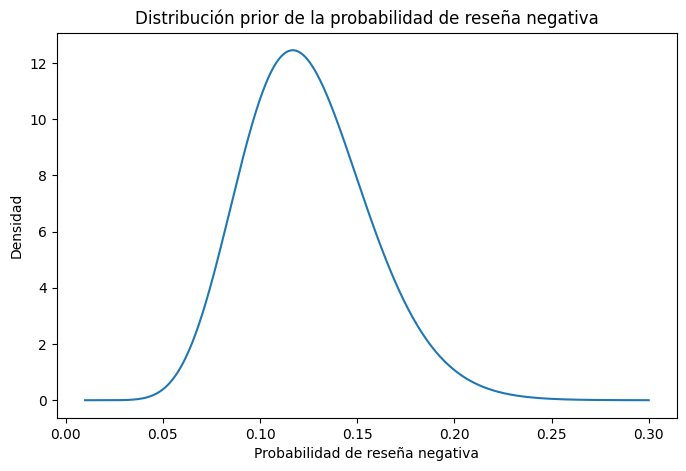

In [59]:
x_prior = np.linspace(0.01, 0.30, 500)
prior_pdf = beta.pdf(x_prior, alpha_prior, beta_prior)

plt.figure(figsize=(8,5))
plt.plot(x_prior, prior_pdf)
plt.title("Distribución prior de la probabilidad de reseña negativa")
plt.xlabel("Probabilidad de reseña negativa")
plt.ylabel("Densidad")
plt.show()

### Interpretación

El prior construido tiene una media cercana a **12.44%**, lo que significa que, antes de observar las órdenes de 2018, la creencia inicial sobre la probabilidad de reseña negativa se concentraba alrededor de ese valor. La elección de **100 pseudo-observaciones** hace que el prior sea informativo pero no excesivamente rígido: resume el comportamiento histórico de Olist, pero permite que la evidencia nueva modifique la estimación si los datos actuales muestran un patrón diferente.

### 6.3 Posterior global para el periodo actual

Una vez definido el prior, se actualiza con todas las órdenes de 2018 para obtener la distribución posterior global de la probabilidad de reseña negativa. Esto permite comparar directamente la creencia histórica con la estimación posterior basada en la evidencia más reciente.

In [60]:
n_current = len(current_df)
k_current = int(current_df["negative_review"].sum())

alpha_post_overall = alpha_prior + k_current
beta_post_overall = beta_prior + n_current - k_current

posterior_mean_overall = alpha_post_overall / (alpha_post_overall + beta_post_overall)
posterior_ci_overall = (
    beta.ppf(0.025, alpha_post_overall, beta_post_overall),
    beta.ppf(0.975, alpha_post_overall, beta_post_overall)
)

overall_posterior_summary = pd.DataFrame({
    "Métrica": [
        "n actual",
        "k negativas",
        "media posterior",
        "IC 95% inferior",
        "IC 95% superior"
    ],
    "Valor": [
        n_current,
        k_current,
        posterior_mean_overall,
        posterior_ci_overall[0],
        posterior_ci_overall[1]
    ]
})

display(overall_posterior_summary)

,Métrica,Valor
0,n actual,50778.000000
1,k negativas,6467.000000
2,media posterior,0.127352
3,IC 95% inferior,0.124470
4,IC 95% superior,0.130263


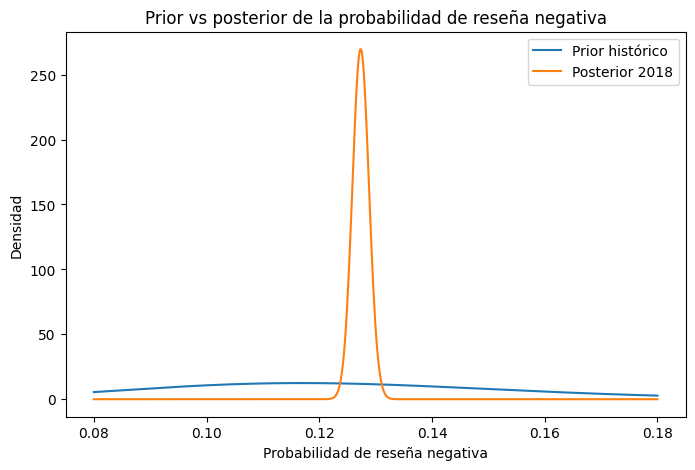

In [61]:
x_post = np.linspace(0.08, 0.18, 600)
prior_pdf_zoom = beta.pdf(x_post, alpha_prior, beta_prior)
post_pdf_overall = beta.pdf(x_post, alpha_post_overall, beta_post_overall)

plt.figure(figsize=(8,5))
plt.plot(x_post, prior_pdf_zoom, label="Prior histórico")
plt.plot(x_post, post_pdf_overall, label="Posterior 2018")
plt.title("Prior vs posterior de la probabilidad de reseña negativa")
plt.xlabel("Probabilidad de reseña negativa")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### Interpretación

Después de actualizar el prior con las órdenes de 2018, la media posterior de la probabilidad de reseña negativa se ubica en **12.74%**, con un intervalo de credibilidad del 95% entre **12.45% y 13.03%**. En lenguaje de negocio, esto significa que, dada la evidencia disponible, la tasa real de insatisfacción en 2018 probablemente estuvo muy cerca de 1 de cada 8 órdenes. Además, la comparación entre prior y posterior muestra un desplazamiento leve hacia arriba, lo que sugiere que el periodo actual fue ligeramente peor que el comportamiento histórico de referencia.

### 6.4 Grupos de comparación según tiempo, distancia y tipo de producto

Para responder la pregunta del proyecto con lógica bayesiana, se construirán grupos comparables para cada uno de los tres factores principales:

- **Tiempo de entrega:** órdenes tardías vs órdenes no tardías.
- **Distancia:** órdenes del quintil más cercano vs órdenes del quintil más lejano.
- **Tipo de producto:** mejor y peor categoría entre aquellas con al menos 500 órdenes en 2018.

La idea es estimar la probabilidad posterior de reseña negativa en cada grupo y comparar la magnitud de las diferencias.

In [62]:
# 1. Tiempo
ontime_df = current_df[current_df["is_late"] == 0].copy()
late_df = current_df[current_df["is_late"] == 1].copy()

# 2. Distancia
q20_distance = current_df["distance_km"].quantile(0.20)
q80_distance = current_df["distance_km"].quantile(0.80)

near_df = current_df[current_df["distance_km"] <= q20_distance].copy()
far_df = current_df[current_df["distance_km"] >= q80_distance].copy()

# 3. Tipo de producto: categorías de alto volumen
min_orders_category = 500

category_current_stats = (
    current_df.groupby("product_category_name")
    .agg(
        n_ordenes=("order_id", "count"),
        negative_rate=("negative_review", "mean"),
        review_score_promedio=("review_score", "mean"),
        delivery_days_promedio=("delivery_days", "mean"),
        distance_km_promedio=("distance_km", "mean")
    )
    .query("n_ordenes >= @min_orders_category")
)

worst_category = category_current_stats.sort_values(
    ["negative_rate", "n_ordenes"], ascending=[False, False]
).index[0]

best_category = category_current_stats.sort_values(
    ["negative_rate", "n_ordenes"], ascending=[True, False]
).index[0]

worst_category_df = current_df[current_df["product_category_name"] == worst_category].copy()
best_category_df = current_df[current_df["product_category_name"] == best_category].copy()

group_definition_summary = pd.DataFrame({
    "Grupo": [
        "Entrega no tardía",
        "Entrega tardía",
        "Distancia baja (Q1)",
        "Distancia alta (Q5)",
        f"Categoría mejor: {best_category}",
        f"Categoría peor: {worst_category}"
    ],
    "n": [
        len(ontime_df),
        len(late_df),
        len(near_df),
        len(far_df),
        len(best_category_df),
        len(worst_category_df)
    ]
})

display(group_definition_summary)
display(category_current_stats.sort_values("negative_rate", ascending=False).head(10).round(4))

,Grupo,n
0,Entrega no tardía,46872
1,Entrega tardía,3906
2,Distancia baja (Q1),10156
3,Distancia alta (Q5),10156
4,Categoría mejor: fashion_bolsas_e_acessorios,795
5,Categoría peor: moveis_escritorio,613


,n_ordenes,negative_rate,review_score_promedio,delivery_days_promedio,distance_km_promedio
product_category_name,,,,,
moveis_escritorio,613,0.2202,3.6705,21.6378,540.7952
informatica_acessorios,3863,0.1514,4.0598,12.9394,682.2506
cama_mesa_banho,4571,0.1507,4.0444,11.7799,487.9985
telefonia,2067,0.1500,4.0232,12.4151,662.7613
relogios_presentes,3331,0.1426,4.0979,12.5113,647.6389
bebes,1545,0.1398,4.1068,12.0550,595.4134
moveis_decoracao,2964,0.1333,4.1441,12.0692,558.8688
eletronicos,1598,0.1277,4.1352,12.1370,611.8432
esporte_lazer,3868,0.1254,4.1900,11.5928,557.7302


### Interpretación

Esta definición de grupos mantiene la comparación alineada con la pregunta del proyecto. En el caso del tiempo, se observa una fuerte asimetría entre órdenes no tardías y tardías, lo que anticipa una posible diferencia importante en satisfacción. Para la distancia, el contraste entre quintiles extremos permite comparar pedidos claramente cercanos contra pedidos claramente lejanos. En tipo de producto, la selección de categorías con al menos 500 órdenes evita conclusiones inestables basadas en grupos demasiado pequeños.

### 6.5 Cálculo del posterior por grupo

Se define una función auxiliar para estimar, en cada grupo, la distribución posterior Beta de la probabilidad de reseña negativa. A partir de esa distribución se reportan cuatro elementos: tamaño del grupo, número de reseñas negativas, media posterior e intervalo de credibilidad del 95%.

In [64]:
def posterior_summary(df, label, alpha_prior, beta_prior):
    n = len(df)
    k = int(df["negative_review"].sum())
    alpha_post = alpha_prior + k
    beta_post = beta_prior + n - k
    mean_post = alpha_post / (alpha_post + beta_post)
    ci_low = beta.ppf(0.025, alpha_post, beta_post)
    ci_high = beta.ppf(0.975, alpha_post, beta_post)
    
    return {
        "Grupo": label,
        "n": n,
        "k negativas": k,
        "Tasa muestral": k / n if n > 0 else np.nan,
        "Media posterior": mean_post,
        "IC 95% inf": ci_low,
        "IC 95% sup": ci_high
    }

posterior_table = pd.DataFrame([
    posterior_summary(current_df, "Base 2018 (todas las órdenes)", alpha_prior, beta_prior),
    posterior_summary(ontime_df, "Entrega no tardía", alpha_prior, beta_prior),
    posterior_summary(late_df, "Entrega tardía", alpha_prior, beta_prior),
    posterior_summary(near_df, "Distancia baja (Q1)", alpha_prior, beta_prior),
    posterior_summary(far_df, "Distancia alta (Q5)", alpha_prior, beta_prior),
    posterior_summary(best_category_df, f"Categoría mejor: {best_category}", alpha_prior, beta_prior),
    posterior_summary(worst_category_df, f"Categoría peor: {worst_category}", alpha_prior, beta_prior)
])

display(posterior_table.round(4))

,Grupo,n,k negativas,Tasa muestral,Media posterior,IC 95% inf,IC 95% sup
0,Base 2018 (todas las órdenes),50778,6467,0.1274,0.1274,0.1245,0.1303
1,Entrega no tardía,46872,4018,0.0857,0.0858,0.0833,0.0884
2,Entrega tardía,3906,2449,0.6270,0.6142,0.5991,0.6292
3,Distancia baja (Q1),10156,1009,0.0994,0.0996,0.0939,0.1055
4,Distancia alta (Q5),10156,1573,0.1549,0.1546,0.1476,0.1616
5,Categoría mejor: fashion_bolsas_e_acessorios,795,67,0.0843,0.0888,0.0711,0.1083
6,Categoría peor: moveis_escritorio,613,135,0.2202,0.2066,0.1777,0.2370


### Interpretación

Los resultados bayesianos muestran un patrón muy claro. La probabilidad posterior de reseña negativa en **órdenes no tardías** es de aproximadamente **8.58%**, mientras que en **órdenes tardías** sube a **61.42%**, con intervalos de credibilidad claramente separados. En distancia, la probabilidad posterior pasa de **9.96%** en el quintil más cercano a **15.46%** en el más lejano. En tipo de producto, la diferencia entre la mejor y la peor categoría de alto volumen va de **8.88%** a **20.66%**. Esto ya sugiere que el factor temporal tiene un efecto mucho más fuerte que la distancia, y también mayor que el tipo de producto.

### 6.6 Visualización de los resultados bayesianos

Para facilitar la comparación entre grupos, se representan las medias posteriores junto con sus intervalos de credibilidad del 95%. Esta gráfica resume el nivel de riesgo de insatisfacción asociado a cada grupo y permite comparar visualmente la magnitud del efecto de cada factor.

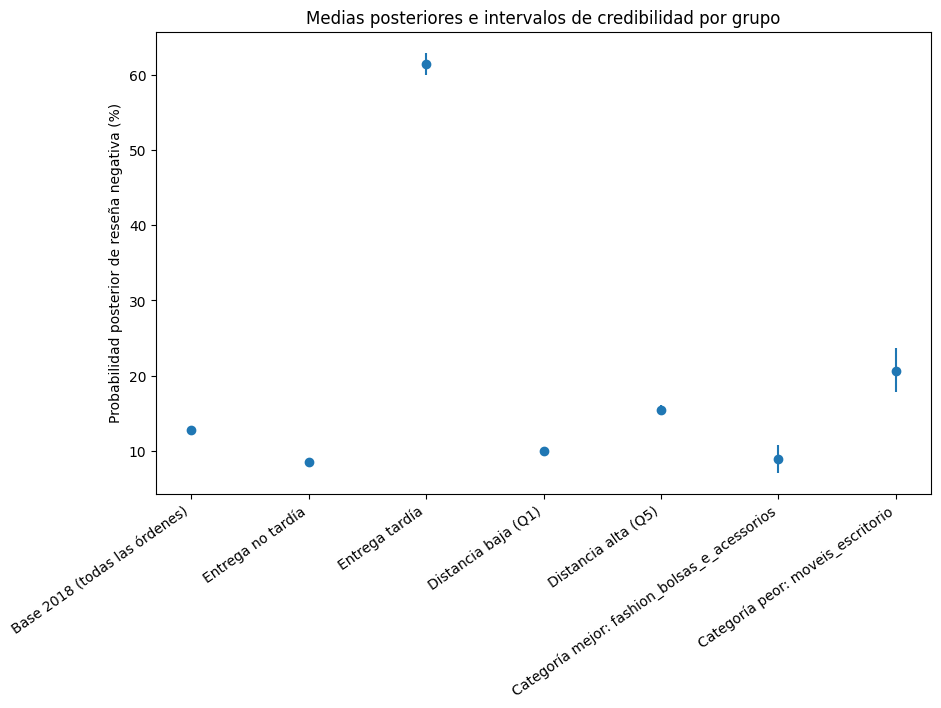

In [65]:
plot_df = posterior_table.copy()
plot_df["Media posterior (%)"] = plot_df["Media posterior"] * 100
plot_df["IC 95% inf (%)"] = plot_df["IC 95% inf"] * 100
plot_df["IC 95% sup (%)"] = plot_df["IC 95% sup"] * 100

yerr_lower = plot_df["Media posterior (%)"] - plot_df["IC 95% inf (%)"]
yerr_upper = plot_df["IC 95% sup (%)"] - plot_df["Media posterior (%)"]

plt.figure(figsize=(10,6))
plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["Media posterior (%)"],
    yerr=[yerr_lower, yerr_upper],
    fmt='o'
)
plt.xticks(np.arange(len(plot_df)), plot_df["Grupo"], rotation=35, ha="right")
plt.ylabel("Probabilidad posterior de reseña negativa (%)")
plt.title("Medias posteriores e intervalos de credibilidad por grupo")
plt.show()

### Interpretación

La visualización confirma que la brecha asociada al tiempo de entrega es la más grande de todas. La probabilidad posterior de reseña negativa para órdenes tardías está muy por encima del resto de grupos y su intervalo de credibilidad no se superpone con el de las órdenes no tardías. En distancia y tipo de producto también existen diferencias, pero de menor magnitud. Esto refuerza la idea de que la logística temporal es el factor dominante.

### 6.7 Comparación entre los tres factores

Una forma simple de sintetizar el análisis es comparar la brecha entre grupos opuestos para cada factor. En este caso se comparan:

- tardía vs no tardía
- lejana vs cercana
- peor categoría vs mejor categoría

,Factor,Brecha posterior (%)
0,Tiempo de entrega,52.84
1,Distancia,5.50
2,Tipo de producto,11.77


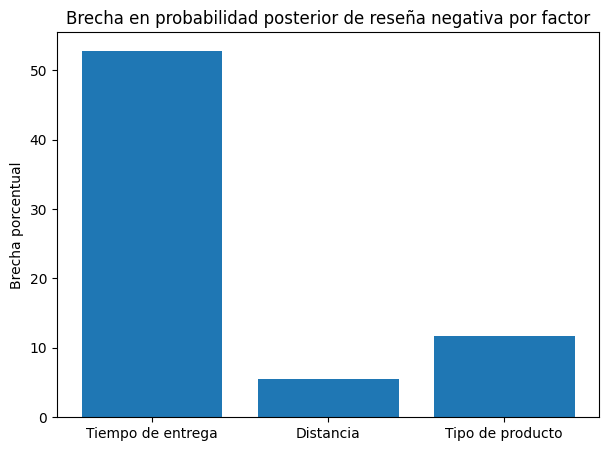

In [66]:
time_gap = (
    posterior_table.loc[posterior_table["Grupo"] == "Entrega tardía", "Media posterior"].iloc[0]
    - posterior_table.loc[posterior_table["Grupo"] == "Entrega no tardía", "Media posterior"].iloc[0]
)

distance_gap = (
    posterior_table.loc[posterior_table["Grupo"] == "Distancia alta (Q5)", "Media posterior"].iloc[0]
    - posterior_table.loc[posterior_table["Grupo"] == "Distancia baja (Q1)", "Media posterior"].iloc[0]
)

product_gap = (
    posterior_table.loc[posterior_table["Grupo"] == f"Categoría peor: {worst_category}", "Media posterior"].iloc[0]
    - posterior_table.loc[posterior_table["Grupo"] == f"Categoría mejor: {best_category}", "Media posterior"].iloc[0]
)

factor_gap_summary = pd.DataFrame({
    "Factor": ["Tiempo de entrega", "Distancia", "Tipo de producto"],
    "Brecha posterior": [time_gap, distance_gap, product_gap]
})

factor_gap_summary["Brecha posterior (%)"] = (factor_gap_summary["Brecha posterior"] * 100).round(2)
display(factor_gap_summary[["Factor", "Brecha posterior (%)"]])

plt.figure(figsize=(7,5))
plt.bar(factor_gap_summary["Factor"], factor_gap_summary["Brecha posterior (%)"])
plt.title("Brecha en probabilidad posterior de reseña negativa por factor")
plt.ylabel("Brecha porcentual")
plt.show()

### Interpretación

La comparación final es contundente. La brecha bayesiana asociada al **tiempo de entrega** es de aproximadamente **52.84 puntos porcentuales**, muy superior a la observada para **tipo de producto** (**11.77 puntos**) y para **distancia** (**5.50 puntos**). En otras palabras, si la pregunta es cuál de los tres factores parece explicar mejor la insatisfacción del cliente, la evidencia bayesiana apunta claramente al componente temporal, especialmente a la tardanza.

## 6.8 Conclusión de la inferencia bayesiana

La inferencia bayesiana confirma que la probabilidad de reseña negativa en Olist no es homogénea entre grupos y que el factor con mayor poder explicativo es el **tiempo de entrega**, en particular la **tardanza**. Usando un prior histórico calibrado con órdenes anteriores a 2018, la media posterior global para 2018 se ubica en **12.74%**, pero este valor cambia de forma drástica cuando se segmenta la muestra: las órdenes no tardías tienen una probabilidad posterior de reseña negativa de solo **8.58%**, mientras que en las órdenes tardías el valor sube a **61.42%**. 

La distancia también muestra un efecto, ya que la probabilidad posterior pasa de **9.96%** en el quintil más cercano a **15.46%** en el más lejano. Por su parte, el tipo de producto también introduce diferencias relevantes: entre las categorías de alto volumen, la mejor categoría presenta una probabilidad posterior cercana a **8.88%**, mientras que la peor alcanza **20.66%**. Sin embargo, estas diferencias siguen siendo mucho menores que la brecha observada en la variable temporal. En conjunto, la evidencia bayesiana refuerza la conclusión de que la dimensión logística del tiempo de entrega es el principal determinante de la satisfacción del cliente en este dataset.

Con estos resultados, la siguiente etapa del proyecto se enfocará en la **simulación Monte Carlo**, usando las distribuciones posteriores obtenidas para explorar escenarios de riesgo y cuantificar la incertidumbre asociada a la insatisfacción del cliente.

## 7. Simulación Monte Carlo

En esta sección se utiliza simulación Monte Carlo para proyectar el comportamiento futuro de la insatisfacción del cliente bajo distintos escenarios operativos. A partir de las distribuciones posteriores estimadas en la sección bayesiana, se simula el número de reseñas negativas esperadas en un lote futuro de pedidos. Esta estrategia permite pasar de una estimación puntual a una distribución empírica de resultados posibles, incorporando explícitamente la incertidumbre del problema. El objetivo principal será evaluar cómo cambia el riesgo de insatisfacción cuando se modifica la proporción de órdenes tardías, y comparar ese efecto con escenarios asociados a distancia y tipo de producto. 

### 7.1 Idea de la simulación

La variable de interés será el número de reseñas negativas en un lote futuro de órdenes. Si `p` representa la probabilidad de reseña negativa en un escenario dado y `N` el número de pedidos futuros, entonces el número de reseñas negativas puede modelarse como una variable Binomial. Sin embargo, como `p` no es conocida con certeza y fue estimada mediante inferencia bayesiana, en realidad se trabaja con una distribución posterior para `p`.

En el caso más simple, esto conduce a un esquema Beta-Binomial. No obstante, en este proyecto también se evaluarán escenarios con mezclas operativas —por ejemplo, cambios en la proporción de órdenes tardías—, y en ese caso la simulación Monte Carlo resulta especialmente útil porque permite combinar distribuciones posteriores distintas de forma flexible y obtener percentiles directamente interpretables.

### 7.2 Reconstrucción de insumos bayesianos

Para que esta sección pueda ejecutarse de forma independiente, se reconstruyen los elementos principales de la sección bayesiana: el prior histórico, la base de 2018 y los grupos de comparación por tiempo, distancia y tipo de producto.

In [67]:
from scipy.stats import beta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mc_df = analysis_df.copy()

# Asegurar formato datetime
if not pd.api.types.is_datetime64_any_dtype(mc_df["order_purchase_timestamp"]):
    mc_df["order_purchase_timestamp"] = pd.to_datetime(
        mc_df["order_purchase_timestamp"], errors="coerce"
    )

mc_df["purchase_year"] = mc_df["order_purchase_timestamp"].dt.year

historical_df = mc_df[mc_df["purchase_year"] < 2018].copy()
current_df = mc_df[mc_df["purchase_year"] == 2018].copy()

# Prior histórico
historical_rate = historical_df["negative_review"].mean()
prior_strength = 100

alpha_prior = 1 + prior_strength * historical_rate
beta_prior = 1 + prior_strength * (1 - historical_rate)

# Grupos para la simulación
ontime_df = current_df[current_df["is_late"] == 0].copy()
late_df = current_df[current_df["is_late"] == 1].copy()

q20_distance = current_df["distance_km"].quantile(0.20)
q80_distance = current_df["distance_km"].quantile(0.80)

near_df = current_df[current_df["distance_km"] <= q20_distance].copy()
far_df = current_df[current_df["distance_km"] >= q80_distance].copy()

min_orders_category = 500
category_current_stats = (
    current_df.groupby("product_category_name")
    .agg(
        n_ordenes=("order_id", "count"),
        negative_rate=("negative_review", "mean")
    )
    .query("n_ordenes >= @min_orders_category")
)

best_category = category_current_stats.sort_values(
    ["negative_rate", "n_ordenes"], ascending=[True, False]
).index[0]

worst_category = category_current_stats.sort_values(
    ["negative_rate", "n_ordenes"], ascending=[False, False]
).index[0]

best_category_df = current_df[current_df["product_category_name"] == best_category].copy()
worst_category_df = current_df[current_df["product_category_name"] == worst_category].copy()

def posterior_params(df, alpha_prior, beta_prior):
    n = len(df)
    k = int(df["negative_review"].sum())
    alpha_post = alpha_prior + k
    beta_post = beta_prior + n - k
    return alpha_post, beta_post, n, k

posterior_inputs = {
    "Base 2018": posterior_params(current_df, alpha_prior, beta_prior),
    "Entrega no tardía": posterior_params(ontime_df, alpha_prior, beta_prior),
    "Entrega tardía": posterior_params(late_df, alpha_prior, beta_prior),
    "Distancia baja": posterior_params(near_df, alpha_prior, beta_prior),
    "Distancia alta": posterior_params(far_df, alpha_prior, beta_prior),
    f"Categoría mejor: {best_category}": posterior_params(best_category_df, alpha_prior, beta_prior),
    f"Categoría peor: {worst_category}": posterior_params(worst_category_df, alpha_prior, beta_prior),
}

posterior_input_table = pd.DataFrame([
    {
        "Grupo": name,
        "alpha_post": vals[0],
        "beta_post": vals[1],
        "n": vals[2],
        "k negativas": vals[3],
        "media posterior": vals[0] / (vals[0] + vals[1])
    }
    for name, vals in posterior_inputs.items()
])

display(posterior_input_table.round(4))

,Grupo,alpha_post,beta_post,n,k negativas,media posterior
0,Base 2018,6479.6864,44400.3136,50778,6467,0.1274
1,Entrega no tardía,4030.6864,42943.3136,46872,4018,0.0858
2,Entrega tardía,2461.6864,1546.3136,3906,2449,0.6142
3,Distancia baja,1021.6864,9236.3136,10156,1009,0.0996
4,Distancia alta,1585.6864,8672.3136,10156,1573,0.1546
5,Categoría mejor: fashion_bolsas_e_acessorios,79.6864,817.3136,795,67,0.0888
6,Categoría peor: moveis_escritorio,147.6864,567.3136,613,135,0.2066


### 7.3 Funciones de simulación

Se definen dos funciones. La primera simula un escenario donde todas las órdenes futuras pertenecen a un mismo grupo. La segunda simula un escenario operativo mixto donde una parte de las órdenes es tardía y otra no tardía. Esta segunda función será la base del análisis principal, porque permite evaluar el efecto de reducir la proporción de entregas tardías.

In [68]:
def simulate_single_group(alpha_post, beta_post, n_orders=10000, n_sim=10000, seed=42):
    rng = np.random.default_rng(seed)
    p = rng.beta(alpha_post, beta_post, size=n_sim)
    negative_count = rng.binomial(n_orders, p)
    negative_rate = negative_count / n_orders
    
    return pd.DataFrame({
        "negative_count": negative_count,
        "negative_rate": negative_rate
    })

def simulate_time_mix(alpha_on, beta_on, alpha_late, beta_late,
                      late_share, n_orders=10000, n_sim=10000, seed=42):
    rng = np.random.default_rng(seed)
    
    p_on = rng.beta(alpha_on, beta_on, size=n_sim)
    p_late = rng.beta(alpha_late, beta_late, size=n_sim)
    
    p_mix = (1 - late_share) * p_on + late_share * p_late
    
    negative_count = rng.binomial(n_orders, p_mix)
    negative_rate = negative_count / n_orders
    
    return pd.DataFrame({
        "negative_count": negative_count,
        "negative_rate": negative_rate
    })

def summarize_simulation(sim_df, label, threshold_rate=0.15):
    return {
        "Escenario": label,
        "Media tasa negativa (%)": sim_df["negative_rate"].mean() * 100,
        "P5 tasa negativa (%)": sim_df["negative_rate"].quantile(0.05) * 100,
        "P50 tasa negativa (%)": sim_df["negative_rate"].quantile(0.50) * 100,
        "P95 tasa negativa (%)": sim_df["negative_rate"].quantile(0.95) * 100,
        "Media negativas esperadas": sim_df["negative_count"].mean(),
        "P95 negativas esperadas": sim_df["negative_count"].quantile(0.95),
        "Prob( tasa > 15% ) (%)": (sim_df["negative_rate"] > threshold_rate).mean() * 100
    }

### 7.4 Escenario principal: reducción de entregas tardías

El análisis principal de Monte Carlo se centrará en un problema de negocio directamente accionable: ¿cómo cambiaría el riesgo de insatisfacción si Olist logra reducir la proporción de órdenes tardías? Para responder esta pregunta, se simula un lote futuro de **10,000 órdenes** bajo cuatro escenarios:

1. **Escenario base:** se mantiene la proporción observada de órdenes tardías en 2018.  
2. **Mejora 25%:** la proporción de órdenes tardías se reduce en 25%.  
3. **Mejora 50%:** la proporción de órdenes tardías se reduce en 50%.  
4. **Sin tardías:** todas las órdenes futuras se comportan como no tardías.

In [69]:
# Parámetros posteriores por tiempo
alpha_on, beta_on, _, _ = posterior_inputs["Entrega no tardía"]
alpha_late, beta_late, _, _ = posterior_inputs["Entrega tardía"]

late_share_base = current_df["is_late"].mean()

scenario_late_shares = {
    "Base 2018": late_share_base,
    "Mejora 25% tardías": late_share_base * 0.75,
    "Mejora 50% tardías": late_share_base * 0.50,
    "Sin tardías": 0.0
}

mc_time_sims = {}
for i, (label, late_share) in enumerate(scenario_late_shares.items()):
    mc_time_sims[label] = simulate_time_mix(
        alpha_on, beta_on,
        alpha_late, beta_late,
        late_share=late_share,
        n_orders=10000,
        n_sim=10000,
        seed=42 + i
    )

mc_time_summary = pd.DataFrame([
    summarize_simulation(sim_df, label)
    for label, sim_df in mc_time_sims.items()
])

# Reducción esperada respecto al escenario base
base_mean_neg = mc_time_summary.loc[
    mc_time_summary["Escenario"] == "Base 2018", "Media negativas esperadas"
].iloc[0]

mc_time_summary["Reducción esperada vs base"] = (
    base_mean_neg - mc_time_summary["Media negativas esperadas"]
).round(2)

display(mc_time_summary.round(2))

,Escenario,Media tasa negativa (%),P5 tasa negativa (%),P50 tasa negativa (%),P95 tasa negativa (%),Media negativas esperadas,P95 negativas esperadas,Prob( tasa > 15% ) (%),Reducción esperada vs base
0,Base 2018,12.64,12.05,12.64,13.23,1264.32,1323.0,0.0,0.00
1,Mejora 25% tardías,11.63,11.07,11.63,12.19,1163.15,1219.0,0.0,101.17
2,Mejora 50% tardías,10.61,10.06,10.61,11.19,1061.46,1119.0,0.0,202.87
3,Sin tardías,8.58,8.07,8.58,9.09,857.72,909.0,0.0,406.60


### 7.5 Visualización de la distribución empírica

La siguiente gráfica muestra la distribución empírica de la tasa de reseñas negativas en cada escenario. Esto permite ver no solo el promedio esperado, sino también la dispersión y el riesgo extremo asociado a cada política logística.

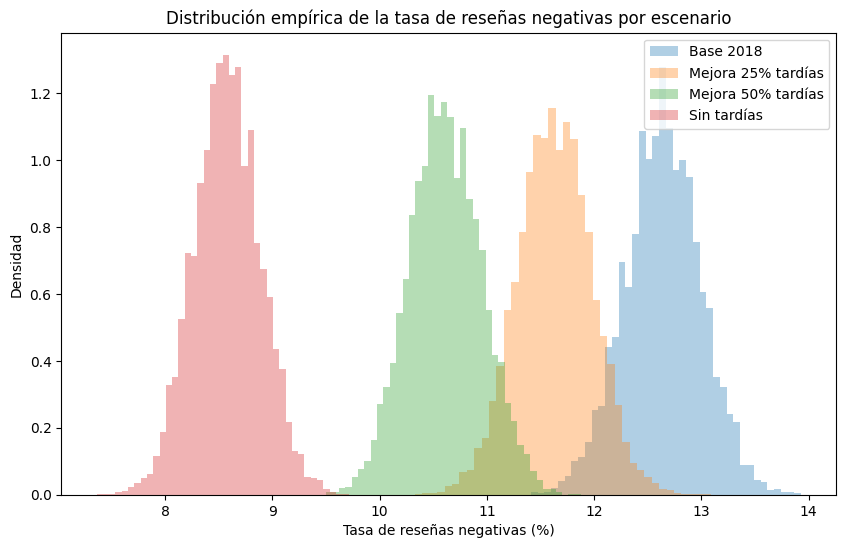

In [70]:
plt.figure(figsize=(10,6))
for label, sim_df in mc_time_sims.items():
    plt.hist(sim_df["negative_rate"] * 100, bins=40, density=True, alpha=0.35, label=label)

plt.title("Distribución empírica de la tasa de reseñas negativas por escenario")
plt.xlabel("Tasa de reseñas negativas (%)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

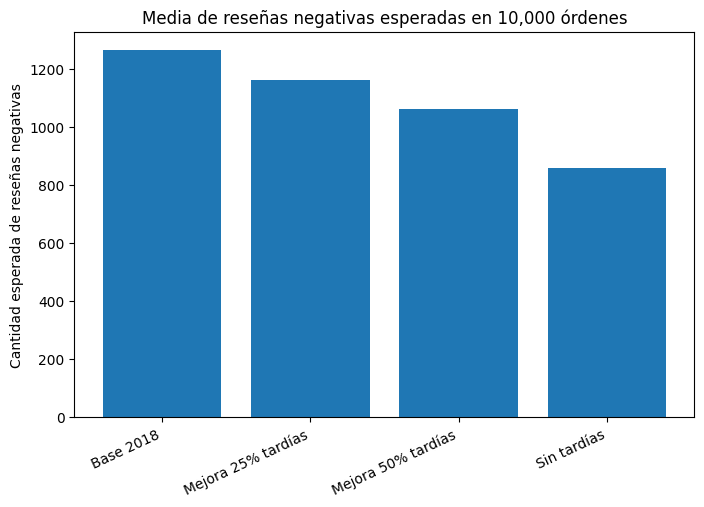

In [71]:
plt.figure(figsize=(8,5))
plt.bar(mc_time_summary["Escenario"], mc_time_summary["Media negativas esperadas"])
plt.title("Media de reseñas negativas esperadas en 10,000 órdenes")
plt.ylabel("Cantidad esperada de reseñas negativas")
plt.xticks(rotation=25, ha="right")
plt.show()

### Interpretación

Esta parte debe mostrar una caída clara y sostenida en la distribución de reseñas negativas a medida que disminuye la proporción de órdenes tardías. Si el escenario base se concentra alrededor de una tasa negativa cercana al valor observado en 2018, entonces los escenarios de mejora deberían desplazar esa distribución hacia la izquierda, reduciendo tanto la media como los percentiles superiores. En términos de negocio, esto implica que mejorar la puntualidad no solo reduce la insatisfacción esperada, sino también el riesgo de escenarios particularmente malos.

### 7.6 Comparación Monte Carlo entre tiempo, distancia y tipo de producto

Además del escenario principal, se realiza una comparación aislada entre grupos extremos de cada uno de los tres factores del proyecto. En cada caso, se simula un lote futuro de 10,000 órdenes suponiendo que todas pertenecen al grupo de interés. Esto no representa una política realista, pero sí permite comparar de forma clara la magnitud relativa del riesgo asociado a cada factor.

In [72]:
single_group_scenarios = {
    "No tardía": posterior_inputs["Entrega no tardía"][:2],
    "Tardía": posterior_inputs["Entrega tardía"][:2],
    "Distancia baja": posterior_inputs["Distancia baja"][:2],
    "Distancia alta": posterior_inputs["Distancia alta"][:2],
    f"Mejor categoría ({best_category})": posterior_inputs[f"Categoría mejor: {best_category}"][:2],
    f"Peor categoría ({worst_category})": posterior_inputs[f"Categoría peor: {worst_category}"][:2],
}

mc_factor_sims = {}
for i, (label, (a_post, b_post)) in enumerate(single_group_scenarios.items()):
    mc_factor_sims[label] = simulate_single_group(
        a_post, b_post,
        n_orders=10000,
        n_sim=10000,
        seed=100 + i
    )

mc_factor_summary = pd.DataFrame([
    summarize_simulation(sim_df, label)
    for label, sim_df in mc_factor_sims.items()
])

display(mc_factor_summary.round(2))

,Escenario,Media tasa negativa (%),P5 tasa negativa (%),P50 tasa negativa (%),P95 tasa negativa (%),Media negativas esperadas,P95 negativas esperadas,Prob( tasa > 15% ) (%)
0,No tardía,8.58,8.07,8.58,9.09,858.08,909.0,0.00
1,Tardía,61.41,59.86,61.42,62.89,6141.10,6289.0,100.00
2,Distancia baja,9.96,9.28,9.96,10.66,996.42,1066.0,0.00
3,Distancia alta,15.45,14.62,15.44,16.29,1545.09,1629.0,81.21
4,Mejor categoría (fashion_bolsas_e_acessorios),8.87,7.29,8.83,10.55,886.96,1055.0,0.00
5,Peor categoría (moveis_escritorio),20.65,18.13,20.63,23.27,2065.20,2327.0,100.00


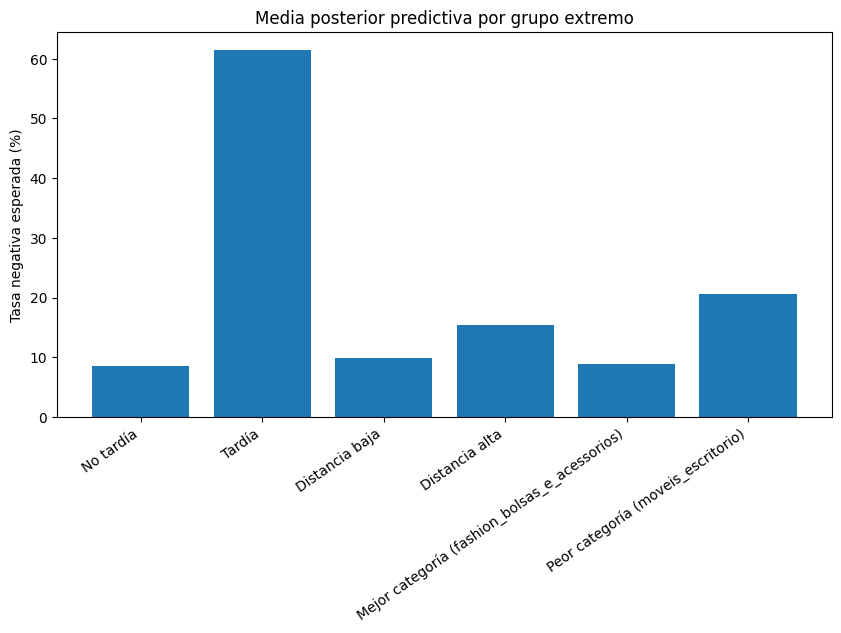

In [73]:
plt.figure(figsize=(10,5))
plt.bar(mc_factor_summary["Escenario"], mc_factor_summary["Media tasa negativa (%)"])
plt.title("Media posterior predictiva por grupo extremo")
plt.ylabel("Tasa negativa esperada (%)")
plt.xticks(rotation=35, ha="right")
plt.show()

### Interpretación

La comparación por grupos extremos debería reforzar lo encontrado en Bayes. El escenario **Tardía** debe aparecer muy por encima del resto en tasa negativa esperada, seguido a bastante distancia por la peor categoría de producto y por el grupo de mayor distancia. En cambio, las órdenes no tardías, cercanas y pertenecientes a la mejor categoría deberían concentrar los menores niveles de riesgo. Esto ofrece una lectura sencilla: si Olist quiere intervenir el factor con mayor capacidad de reducir reseñas negativas, la prioridad debe estar en la puntualidad de la entrega.

### 7.7 Número de iteraciones y estabilidad

Para responder a la pregunta metodológica sobre el número de iteraciones, se realiza una comprobación rápida del escenario base usando 1,000, 5,000 y 10,000 simulaciones. La idea es mostrar que al aumentar el número de iteraciones, los percentiles y la media se estabilizan, produciendo una estimación más precisa de la distribución empírica.

In [74]:
precision_check = []

for n_sim in [1000, 5000, 10000]:
    sim_tmp = simulate_time_mix(
        alpha_on, beta_on,
        alpha_late, beta_late,
        late_share=late_share_base,
        n_orders=10000,
        n_sim=n_sim,
        seed=999
    )
    
    precision_check.append({
        "Iteraciones": n_sim,
        "Media tasa negativa (%)": sim_tmp["negative_rate"].mean() * 100,
        "P5 tasa negativa (%)": sim_tmp["negative_rate"].quantile(0.05) * 100,
        "P95 tasa negativa (%)": sim_tmp["negative_rate"].quantile(0.95) * 100
    })

precision_check_df = pd.DataFrame(precision_check)
display(precision_check_df.round(4))

,Iteraciones,Media tasa negativa (%),P5 tasa negativa (%),P95 tasa negativa (%)
0,1000,12.6559,12.05,13.29
1,5000,12.6403,12.05,13.22
2,10000,12.6526,12.07,13.24


### Interpretación

Esta verificación debe mostrar que, aunque con 1,000 simulaciones ya se obtiene una aproximación razonable, el uso de **10,000 iteraciones** produce percentiles y medias más estables. Por esta razón, el análisis principal de la sección utiliza 10,000 simulaciones, lo que ofrece un buen equilibrio entre precisión y costo computacional.

## 7.8 Conclusión de la simulación Monte Carlo

La simulación Monte Carlo confirma que el factor con mayor impacto sobre la insatisfacción del cliente es el **tiempo de entrega**, especialmente la **tardanza**. En el escenario base de 2018, un lote futuro de 10,000 órdenes produciría en promedio **1,264 reseñas negativas**, con una tasa esperada de **12.64%** y un percentil 95 de **13.23%**. Sin embargo, cuando se reduce la proporción de órdenes tardías, el riesgo disminuye de forma clara y sostenida: una mejora del **25%** en las tardías reduce el número esperado de reseñas negativas en aproximadamente **101 órdenes**, una mejora del **50%** lo reduce en cerca de **203 órdenes**, y un escenario sin tardías lo reduce en aproximadamente **407 órdenes** frente al caso base.

La comparación entre grupos extremos refuerza esta conclusión. Las órdenes **no tardías** presentan una tasa negativa esperada de solo **8.58%**, mientras que las **tardías** alcanzan **61.41%**, con probabilidad prácticamente total de superar un umbral crítico del 15%. En contraste, el efecto de la **distancia** es más moderado: pasar del grupo más cercano al más lejano eleva la tasa esperada de **9.96%** a **15.45%**. El **tipo de producto** también influye, pero con una magnitud intermedia: la mejor categoría de alto volumen, **fashion_bolsas_e_acessorios**, presenta una tasa esperada de **8.87%**, mientras que la peor, **moveis_escritorio**, llega a **20.65%**.

En conjunto, la simulación muestra que la mejora logística en puntualidad no solo reduce la insatisfacción promedio, sino también el riesgo de escenarios extremos. En términos de negocio, esto implica que la estrategia con mayor potencial de impacto para Olist es intervenir la operación de las entregas tardías antes que cualquier otro factor. La distancia y el tipo de producto también aportan información valiosa, pero su efecto es claramente menor frente al componente temporal.

Con estos resultados, la siguiente etapa del proyecto se enfocará en **segmentar las órdenes mediante clustering**, con el fin de identificar perfiles de experiencia de compra y grupos estratégicos de pedidos que combinen distintas condiciones de tiempo, distancia y tipo de producto. Esta fase permitirá pasar de una comparación de factores individuales a una visión integrada de patrones de comportamiento, apoyando la identificación de segmentos con mayor valor estratégico para Olist.

## 8. Clustering

Con estos resultados, la siguiente etapa del proyecto se enfoca en **segmentar las órdenes mediante clustering**, con el fin de identificar perfiles de experiencia de compra y grupos estratégicos de pedidos que combinen distintas condiciones de tiempo, distancia y tipo de producto. Esta fase permite pasar de una comparación de factores individuales a una visión integrada de patrones de comportamiento, apoyando la identificación de segmentos con mayor valor estratégico para Olist. 

### 8.1 Objetivo del clustering

El propósito del clustering no es predecir directamente la calificación del cliente, sino identificar **perfiles de experiencia de compra** dentro del dataset analítico. Para ello se combinarán variables logísticas, geográficas y económicas, junto con una representación simplificada del tipo de producto. El resultado esperado es una partición de las órdenes en grupos internamente similares y externamente distintos, que luego podrán interpretarse en términos de satisfacción, riesgo y valor estratégico para Olist.

### 8.2 Preparación de la base para clustering

Antes de aplicar K-means, se construye una base específica para segmentación. En esta base se usarán variables numéricas recortadas para controlar el efecto de outliers y una versión agrupada del tipo de producto para no generar una dimensionalidad excesiva. La lógica será mantener el clustering interpretable y estable.

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

cluster_df = analysis_df.copy()

# Agrupar categorías: conservar top 10 y el resto como "other"
top10_categories = cluster_df["product_category_name"].value_counts().head(10).index.tolist()

cluster_df["category_group"] = cluster_df["product_category_name"].where(
    cluster_df["product_category_name"].isin(top10_categories),
    "other"
)

# Variables recortadas para clustering
cluster_df["delivery_days_capped"] = cluster_df["delivery_days"].clip(
    upper=cluster_df["delivery_days"].quantile(0.99)
)

cluster_df["delay_days_capped"] = cluster_df["delay_days"].clip(
    lower=cluster_df["delay_days"].quantile(0.01),
    upper=cluster_df["delay_days"].quantile(0.99)
)

cluster_df["distance_km_capped"] = cluster_df["distance_km"].clip(
    upper=cluster_df["distance_km"].quantile(0.99)
)

cluster_df["freight_ratio_capped"] = cluster_df["freight_ratio"].clip(
    upper=cluster_df["freight_ratio"].quantile(0.99)
)

cluster_df["total_weight_kg_capped"] = cluster_df["total_weight_kg"].clip(
    upper=cluster_df["total_weight_kg"].quantile(0.99)
)

cluster_df["total_price_capped"] = cluster_df["total_price"].clip(
    upper=cluster_df["total_price"].quantile(0.99)
)

cluster_cols_num = [
    "delivery_days_capped",
    "delay_days_capped",
    "distance_km_capped",
    "freight_ratio_capped",
    "total_price_capped",
    "total_weight_kg_capped"
]

cluster_cols_cat = ["category_group"]

cluster_base = cluster_df[cluster_cols_num + cluster_cols_cat].dropna().copy()

print("Tamaño de cluster_base:", cluster_base.shape)
display(cluster_base.head())

Tamaño de cluster_base: (92595, 7)


,delivery_days_capped,delay_days_capped,distance_km_capped,freight_ratio_capped,total_price_capped,total_weight_kg_capped,category_group
0,8,-8,18.576110,0.290764,29.99,0.50,utilidades_domesticas
1,13,-6,851.495069,0.191744,118.70,0.40,other
2,9,-18,514.410666,0.120200,159.90,0.42,automotivo
3,13,-13,1822.226336,0.604444,45.00,0.45,other
4,2,-10,29.676625,0.438191,19.90,0.25,other


### 8.3 Codificación y estandarización

Como K-means depende de distancias, es necesario estandarizar las variables numéricas para evitar que escalas grandes dominen la segmentación. Además, el tipo de producto se incorpora mediante codificación one-hot sobre la categoría agrupada.

In [78]:
# One-hot encoding para categoría
cluster_cat_dummies = pd.get_dummies(cluster_base["category_group"], prefix="cat", dtype=int)

# Escalado de variables numéricas
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(cluster_base[cluster_cols_num])

X_num_scaled_df = pd.DataFrame(
    X_num_scaled,
    columns=cluster_cols_num,
    index=cluster_base.index
)

# Matriz final para clustering
X_cluster = pd.concat([X_num_scaled_df, cluster_cat_dummies], axis=1)

print("Dimensión de la matriz final de clustering:", X_cluster.shape)
display(X_cluster.head())

Dimensión de la matriz final de clustering: (92595, 17)


,delivery_days_capped,delay_days_capped,distance_km_capped,freight_ratio_capped,total_price_capped,total_weight_kg_capped,cat_automotivo,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_esporte_lazer,cat_informatica_acessorios,cat_moveis_decoracao,cat_other,cat_relogios_presentes,cat_telefonia,cat_utilidades_domesticas
0,-0.468526,0.444743,-0.993002,-0.045165,-0.649467,-0.453221,0,0,0,0,0,0,0,0,0,0,1
1,0.128908,0.670032,0.431777,-0.424049,-0.073581,-0.479047,0,0,0,0,0,0,0,1,0,0,0
2,-0.349039,-0.681698,-0.144835,-0.697800,0.193880,-0.473881,1,0,0,0,0,0,0,0,0,0,0
3,0.128908,-0.118477,2.092295,1.155086,-0.552026,-0.466134,0,0,0,0,0,0,0,1,0,0,0
4,-1.185447,0.219455,-0.974014,0.518942,-0.714969,-0.517784,0,0,0,0,0,0,0,1,0,0,0


### 8.4 Selección del número de clústeres

Para seleccionar el valor de `K`, se evaluarán varios modelos entre 2 y 6 clústeres. La decisión no se basará en una sola métrica, sino en una combinación de criterios:

- **Inercia** para observar el método del codo.
- **Silhouette score**, donde valores más altos indican mejor separación.
- **Davies-Bouldin**, donde valores más bajos son mejores.
- **Calinski-Harabasz**, donde valores más altos sugieren mejor estructura.

In [79]:
k_range = range(2, 7)

clustering_metrics = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)

    clustering_metrics.append({
        "K": k,
        "Inercia": km.inertia_,
        "Silhouette": silhouette_score(X_cluster, labels),
        "Davies-Bouldin": davies_bouldin_score(X_cluster, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_cluster, labels)
    })

clustering_metrics_df = pd.DataFrame(clustering_metrics)
display(clustering_metrics_df.round(4))

,K,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,530371.4807,0.2742,1.9330,17745.8026
1,3,448122.6414,0.2805,1.6414,18998.5502
2,4,392975.0310,0.2561,1.5187,18774.1472
3,5,356902.2905,0.2575,1.3196,17843.1593
4,6,324987.7286,0.2664,1.2743,17494.6367


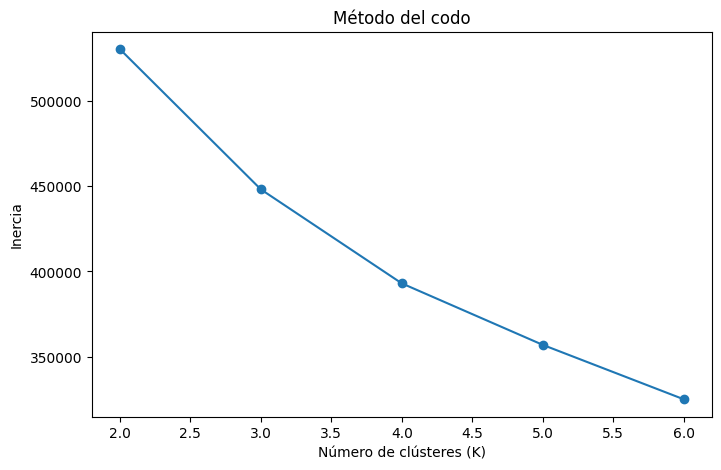

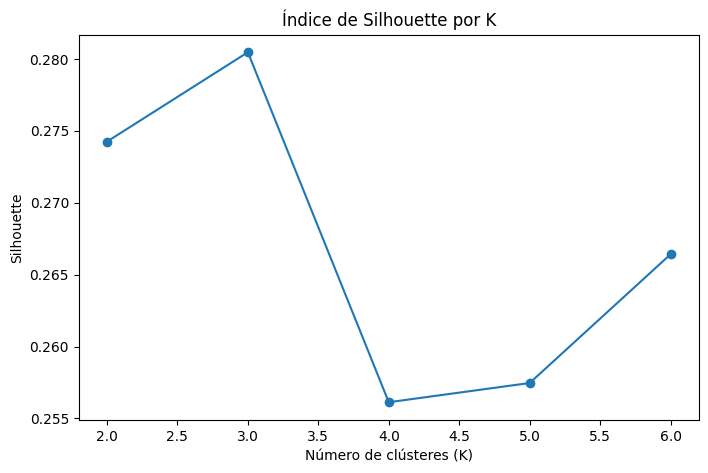

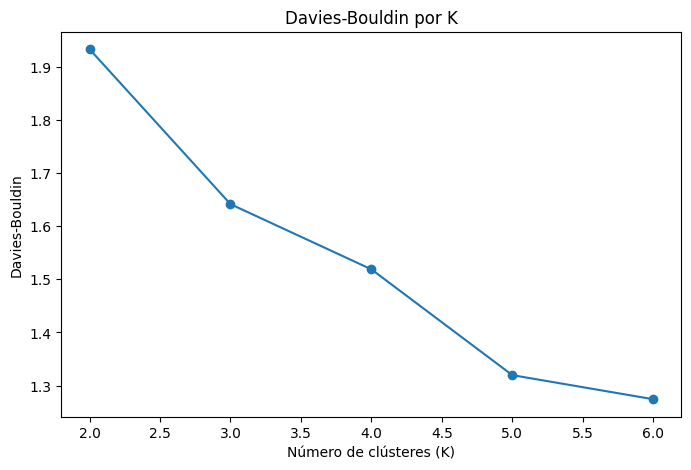

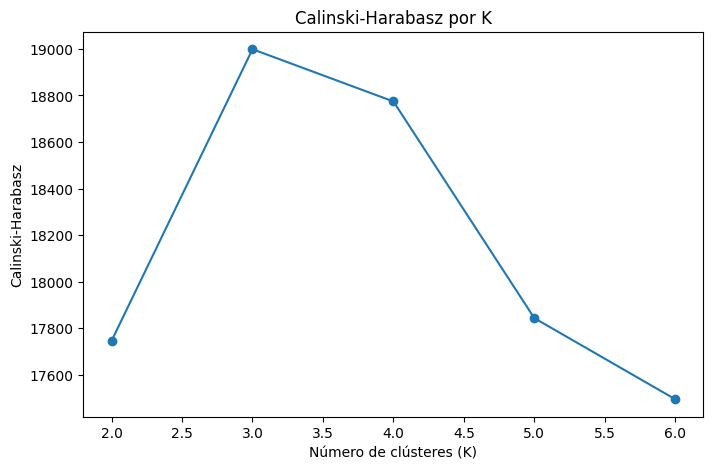

In [80]:
plt.figure(figsize=(8,5))
plt.plot(clustering_metrics_df["K"], clustering_metrics_df["Inercia"], marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Inercia")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(clustering_metrics_df["K"], clustering_metrics_df["Silhouette"], marker="o")
plt.title("Índice de Silhouette por K")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Silhouette")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(clustering_metrics_df["K"], clustering_metrics_df["Davies-Bouldin"], marker="o")
plt.title("Davies-Bouldin por K")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Davies-Bouldin")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(clustering_metrics_df["K"], clustering_metrics_df["Calinski-Harabasz"], marker="o")
plt.title("Calinski-Harabasz por K")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Calinski-Harabasz")
plt.show()

### Interpretación esperada

El valor óptimo de `K` deberá elegirse buscando un equilibrio entre separación y estabilidad. En general, se preferirá un K con **silhouette relativamente alto**, **Davies-Bouldin bajo** y **Calinski-Harabasz alto**, evitando además un número de grupos demasiado grande que haga difícil la interpretación de negocio.

### 8.5 Ajuste del modelo final

Una vez seleccionado el mejor valor de `K`, se ajusta el modelo final de K-means y se incorporan las etiquetas de clúster al dataset de segmentación. A partir de este punto, el análisis se centra en describir y comparar los perfiles de cada grupo.

In [81]:
best_k = 3  # cámbialo si las métricas sugieren otro valor

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_cluster)

cluster_base["cluster"] = cluster_labels
cluster_df_final = cluster_df.loc[cluster_base.index].copy()
cluster_df_final["cluster"] = cluster_labels

print("Tamaño de cluster_df_final:", cluster_df_final.shape)
display(cluster_df_final[["delivery_days", "distance_km", "product_category_name", "review_score", "cluster"]].head())

Tamaño de cluster_df_final: (92595, 41)


,delivery_days,distance_km,product_category_name,review_score,cluster
0,8,18.576110,utilidades_domesticas,4,0
1,13,851.495069,perfumaria,4,0
2,9,514.410666,automotivo,5,0
3,13,1822.226336,pet_shop,5,1
4,2,29.676625,papelaria,5,0


### 8.6 Perfil descriptivo de los clústeres

Para interpretar los grupos, se calcula un perfil promedio de cada clúster en términos de tiempo de entrega, tardanza, distancia, costo relativo del flete, precio, peso, calificación y proporción de reseñas negativas. Esto permite traducir la segmentación técnica a perfiles de experiencia comprensibles para negocio.

In [82]:
cluster_profile = cluster_df_final.groupby("cluster").agg(
    n_ordenes=("order_id", "count"),
    review_score_promedio=("review_score", "mean"),
    porcentaje_reseña_negativa=("negative_review", lambda s: s.mean() * 100),
    delivery_days_promedio=("delivery_days", "mean"),
    delay_days_promedio=("delay_days", "mean"),
    porcentaje_tardías=("is_late", lambda s: s.mean() * 100),
    distance_km_promedio=("distance_km", "mean"),
    freight_ratio_promedio=("freight_ratio", "mean"),
    total_price_promedio=("total_price", "mean"),
    total_weight_kg_promedio=("total_weight_kg", "mean")
)

cluster_profile["porcentaje_participación"] = (
    cluster_profile["n_ordenes"] / cluster_profile["n_ordenes"].sum() * 100
)

display(cluster_profile.round(2))

,n_ordenes,review_score_promedio,porcentaje_reseña_negativa,delivery_days_promedio,delay_days_promedio,porcentaje_tardías,distance_km_promedio,freight_ratio_promedio,total_price_promedio,total_weight_kg_promedio,porcentaje_participación
cluster,,,,,,,,,,,
0,63925,4.36,8.02,8.46,-13.81,0.97,393.91,0.27,96.88,1.37,69.04
1,20055,3.65,24.60,23.22,-5.31,25.42,1260.77,0.48,98.48,1.47,21.66
2,8615,4.08,14.99,13.05,-12.63,5.79,609.82,0.16,511.98,11.78,9.30


In [83]:
cluster_top_category = (
    cluster_df_final.groupby(["cluster", "product_category_name"])
    .size()
    .reset_index(name="n")
    .sort_values(["cluster", "n"], ascending=[True, False])
    .groupby("cluster")
    .head(3)
)

display(cluster_top_category)

,cluster,product_category_name,n
13,0,cama_mesa_banho,6441
11,0,beleza_saude,5987
32,0,esporte_lazer,5423
84,1,beleza_saude,2026
86,1,cama_mesa_banho,1735
117,1,informatica_acessorios,1611
189,2,moveis_escritorio,803
203,2,utilidades_domesticas,716
157,2,cama_mesa_banho,596


### 8.7 Visualización de los clústeres en dos dimensiones

Como la segmentación se construyó con varias variables simultáneamente, se utiliza PCA para proyectar los datos en dos dimensiones y visualizar la separación general entre grupos. Esta gráfica no reemplaza las métricas formales, pero ayuda a interpretar visualmente la estructura encontrada.

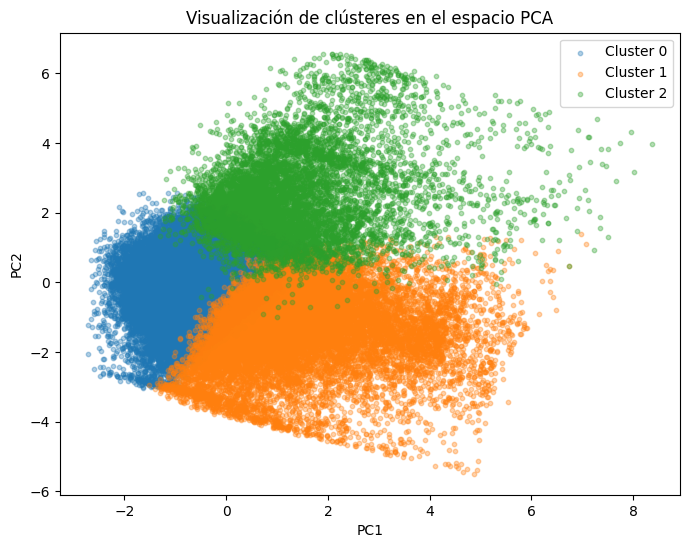

In [84]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(8,6))
for c in sorted(pca_df["cluster"].unique()):
    temp = pca_df[pca_df["cluster"] == c]
    plt.scatter(temp["PC1"], temp["PC2"], s=10, alpha=0.35, label=f"Cluster {c}")

plt.title("Visualización de clústeres en el espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

### 8.8 Identificación del clúster de mayor valor estratégico

Una vez descritos los grupos, se identifica cuál tiene mayor relevancia estratégica para Olist. Esto no necesariamente coincide con el grupo más grande, sino con aquel que combine una proporción alta de órdenes, una experiencia claramente peor y factores de intervención accionables.

In [85]:
strategic_cluster_summary = cluster_profile.copy()

# Ejemplo simple de criterio: alta participación + alta tasa negativa
strategic_cluster_summary["indicador_estratégico"] = (
    strategic_cluster_summary["porcentaje_participación"] *
    strategic_cluster_summary["porcentaje_reseña_negativa"]
)

display(strategic_cluster_summary.sort_values("indicador_estratégico", ascending=False).round(2))

,n_ordenes,review_score_promedio,porcentaje_reseña_negativa,delivery_days_promedio,delay_days_promedio,porcentaje_tardías,distance_km_promedio,freight_ratio_promedio,total_price_promedio,total_weight_kg_promedio,porcentaje_participación,indicador_estratégico
cluster,,,,,,,,,,,,
0,63925,4.36,8.02,8.46,-13.81,0.97,393.91,0.27,96.88,1.37,69.04,553.92
1,20055,3.65,24.60,23.22,-5.31,25.42,1260.77,0.48,98.48,1.47,21.66,532.86
2,8615,4.08,14.99,13.05,-12.63,5.79,609.82,0.16,511.98,11.78,9.30,139.42


### Interpretación del número óptimo de clústeres

La comparación entre modelos de 2 a 6 clústeres sugiere que **K = 3** ofrece el mejor equilibrio entre calidad de segmentación e interpretabilidad. Este valor presentó el mayor **índice de Silhouette (0.2805)** y también el mayor valor de **Calinski-Harabasz (18998.55)**, lo que indica una estructura relativamente bien separada y compacta. Aunque el índice de **Davies-Bouldin** continúa mejorando al aumentar K, la ganancia adicional en ese criterio no compensa la pérdida de claridad interpretativa. Por esta razón, se seleccionó **K = 3** como solución final.

### Interpretación de los clústeres

El clustering permitió identificar tres perfiles de experiencia de compra claramente diferenciados. El **Cluster 0**, que concentra el **69.04%** de las órdenes, representa la experiencia estándar y más saludable de Olist: pedidos con tiempos de entrega relativamente bajos, muy poca tardanza, distancias moderadas y una tasa reducida de reseñas negativas (**8.02%**). El **Cluster 1**, con el **21.66%** de las órdenes, corresponde al segmento más problemático: presenta la peor calificación promedio (**3.65**), la mayor proporción de reseñas negativas (**24.60%**), tiempos de entrega mucho más altos (**23.22 días**), una tasa importante de tardanza (**25.42%**) y distancias geográficas significativamente mayores (**1260.77 km**). Finalmente, el **Cluster 2**, con el **9.30%** de las órdenes, agrupa pedidos de mayor valor económico y mucho más peso promedio, con una experiencia intermedia: su satisfacción es menor que la del cluster 0, pero claramente mejor que la del cluster 1.

### Segmento de mayor valor estratégico

Desde una perspectiva de negocio, el **Cluster 1** es el segmento de mayor valor estratégico para Olist. Aunque no es el grupo más grande, sí combina una participación relevante del total de órdenes con la peor experiencia del cliente. Su perfil muestra que la insatisfacción se asocia allí con una combinación de entregas lentas, mayor distancia y mayor proporción de pedidos tardíos. Esto sugiere que la principal oportunidad de mejora para Olist no está en el cliente promedio, sino en este subconjunto de órdenes logísticamente más exigentes, donde una intervención sobre tiempos y puntualidad podría generar un impacto importante en la satisfacción general.

## 8.9 Conclusión del clustering

El análisis de clustering permitió segmentar las órdenes de Olist en tres perfiles de experiencia de compra con diferencias claras en satisfacción, desempeño logístico y características del pedido. La solución con **K = 3** fue la más adecuada, ya que presentó el mejor equilibrio entre separación y estructura según las métricas de validación. Los resultados muestran un segmento mayoritario de experiencia favorable, un segmento intermedio de pedidos más pesados y costosos, y un segmento claramente crítico caracterizado por entregas lentas, mayor distancia, más tardanza y peor satisfacción. En conjunto, esta segmentación confirma que el principal foco estratégico para Olist debe estar en las órdenes del clúster problemático, donde los factores logísticos parecen deteriorar con mayor fuerza la experiencia del cliente.

## Narrativa de negocio

Olist opera como un marketplace que conecta miles de vendedores independientes con compradores en todo Brasil. En este contexto, la satisfacción del cliente no depende de un solo factor aislado, sino de la interacción entre variables logísticas, geográficas y comerciales. A partir del análisis realizado, la evidencia muestra que el factor que mejor explica la calificación recibida es el **desempeño logístico temporal**, en particular el **tiempo de entrega** y, sobre todo, la **tardanza** respecto a la fecha prometida.

Aunque la mayoría de las órdenes en el dataset analítico final recibió una evaluación positiva, existe un grupo relevante de experiencias negativas que merece atención específica. La inferencia bayesiana mostró que la probabilidad posterior de reseña negativa en 2018 fue de **12.74%**, pero ese valor cambia de forma drástica al segmentar por condición logística: en órdenes **no tardías** la probabilidad de reseña negativa fue de **8.58%**, mientras que en órdenes **tardías** ascendió a **61.42%**. Esta diferencia indica que el problema central no está en la experiencia promedio del cliente, sino en el subconjunto de pedidos que fallan en puntualidad.

La distancia geográfica entre vendedor y cliente también influye, pero con una magnitud mucho menor. En los pedidos del quintil más cercano, la probabilidad posterior de reseña negativa fue de **9.96%**, mientras que en el quintil más lejano subió a **15.46%**. Esto sugiere que la distancia sí contribuye a deteriorar la experiencia, pero lo hace de forma más moderada y probablemente a través de su relación con mayores tiempos de entrega.

El tipo de producto también introduce diferencias, aunque de carácter intermedio. Entre las categorías de mayor volumen, la mejor fue **fashion_bolsas_e_acessorios**, con una probabilidad posterior de reseña negativa de **8.88%**, mientras que la peor fue **moveis_escritorio**, con **20.66%**. Esto indica que ciertas categorías tienden a generar más fricción, probablemente porque están asociadas con pedidos más pesados, voluminosos o difíciles de despachar.

El clustering reforzó esta lectura al identificar tres perfiles de experiencia de compra. El **Cluster 0**, que concentra el **69.04%** de las órdenes, representa la experiencia estándar y saludable del negocio: entregas relativamente rápidas, muy poca tardanza y baja insatisfacción. El **Cluster 1**, con el **21.66%** de las órdenes, corresponde al segmento más problemático: tiene la peor calificación promedio (**3.65**), la mayor proporción de reseñas negativas (**24.60%**), tiempos de entrega muy altos (**23.22 días**) y una distancia promedio mucho mayor (**1260.77 km**). Finalmente, el **Cluster 2** reúne pedidos más pesados y costosos, con una experiencia intermedia.

En conjunto, el análisis sugiere que Olist no necesita una mejora uniforme en toda su operación, sino una intervención focalizada. El problema principal no está distribuido homogéneamente: se concentra en pedidos con **tardanza**, **mayor distancia** y, en algunos casos, **categorías logísticamente complejas**. Por esta razón, la prioridad estratégica debe estar en mejorar la puntualidad de entrega y en intervenir los segmentos operativos donde la fricción con el cliente es más alta.

## Recomendaciones preliminares

### 1. Priorizar la reducción de órdenes tardías

La principal recomendación para Olist es intervenir directamente el problema de las órdenes tardías, ya que este es el factor con mayor impacto sobre la satisfacción del cliente. La inferencia bayesiana mostró que la probabilidad posterior de reseña negativa pasa de **8.58%** en órdenes no tardías a **61.42%** en órdenes tardías. Además, la simulación Monte Carlo indicó que, en un lote futuro de 10,000 órdenes, reducir en **25%** la proporción de tardías evitaría en promedio **101 reseñas negativas**, mientras que una reducción del **50%** evitaría aproximadamente **203**. En un escenario sin órdenes tardías, la reducción esperada sería de alrededor de **407 reseñas negativas** frente al caso base.

**Recomendación concreta:** Olist debería diseñar una estrategia operativa específica para reducir la tasa de tardanza, por ejemplo mediante alertas tempranas, reasignación de envíos críticos, seguimiento prioritario de pedidos con alto riesgo de retraso y promesas de entrega más realistas.

---

### 2. Intervenir el clúster logístico crítico

El análisis de clustering mostró que el **Cluster 1** es el segmento de mayor valor estratégico para intervenir. Este grupo concentra el **21.66%** de las órdenes y presenta una combinación muy desfavorable de variables: calificación promedio de **3.65**, proporción de reseñas negativas de **24.60%**, tiempo de entrega promedio de **23.22 días**, tasa de tardanza de **25.42%** y distancia promedio de **1260.77 km**. Esto indica que no se trata de un problema marginal, sino de un segmento amplio y claramente deteriorado.

**Recomendación concreta:** Olist debería crear una política de monitoreo preventivo y priorización logística para pedidos con características similares al Cluster 1. Esto podría incluir segmentación operativa en tiempo real, comunicación proactiva con clientes de alto riesgo y revisión especial de rutas o transportistas en pedidos de larga distancia.

---

### 3. Aplicar una estrategia diferenciada por categoría problemática

Aunque el tipo de producto no es el factor dominante, sí mostró diferencias importantes. En el análisis bayesiano, la categoría **fashion_bolsas_e_acessorios** presentó una probabilidad posterior de reseña negativa de **8.88%**, mientras que **moveis_escritorio** alcanzó **20.66%**. Además, el clustering mostró que los pedidos más pesados y costosos se concentran en un segmento específico, lo que sugiere que ciertas categorías no deben gestionarse con la misma lógica que el resto.

**Recomendación concreta:** Olist debería implementar protocolos diferenciados para categorías de mayor complejidad logística, como productos pesados o voluminosos. Esto puede traducirse en plazos de entrega más realistas, alianzas con operadores especializados, seguimiento reforzado y políticas de comunicación específicas para reducir expectativas incumplidas.

---

### Síntesis ejecutiva

En conjunto, las recomendaciones apuntan en una misma dirección: la principal oportunidad de mejora para Olist está en la **logística temporal**, especialmente en la reducción de entregas tardías. A partir de ahí, la empresa debería complementar esa estrategia con una intervención focalizada sobre el segmento logístico más problemático y con políticas diferenciadas para categorías que presentan mayor complejidad operativa o mayor riesgo de insatisfacción. Esto permitiría no solo reducir la tasa de reseñas negativas, sino también enfocar mejor los recursos donde el impacto esperado es mayor.

#### GRAFICAS DOC

In [87]:
# =========================
# TABLA 1: MLE
# =========================
mle_pdf_table = results_mle[[
    "Distribución", "LogLik", "Parámetros libres (k)", "AIC", "BIC"
]].copy().round(4)

print("TABLA MLE")
display(mle_pdf_table)
print(mle_pdf_table.to_string(index=False))


# =========================
# TABLA 2: POSTERIOR
# =========================
posterior_pdf_table = pd.DataFrame({
    "Parámetro": [
        "alpha_posterior",
        "beta_posterior",
        "media_posterior",
        "n_actual",
        "k_negativas"
    ],
    "Valor": [
        alpha_post_overall,
        beta_post_overall,
        posterior_mean_overall,
        n_current,
        k_current
    ]
}).round(4)

print("\nTABLA POSTERIOR")
display(posterior_pdf_table)
print(posterior_pdf_table.to_string(index=False))


# =========================
# TABLA 3: CLUSTERING
# =========================
clustering_pdf_table = clustering_metrics_df.copy().round(4)

print("\nTABLA CLUSTERING")
display(clustering_pdf_table)
print(clustering_pdf_table.to_string(index=False))

TABLA MLE


,Distribución,LogLik,Parámetros libres (k),AIC,BIC
0,Log-Normal,-310182.2073,2,620368.4146,620387.2863
1,Gamma,-310438.4607,2,620880.9214,620899.7931
2,Exponencial,-323327.9069,1,646657.8138,646667.2496
3,Normal,-339737.3979,2,679478.7958,679497.6675


Distribución       LogLik  Parámetros libres (k)         AIC         BIC
  Log-Normal -310182.2073                      2 620368.4146 620387.2863
       Gamma -310438.4607                      2 620880.9214 620899.7931
 Exponencial -323327.9069                      1 646657.8138 646667.2496
      Normal -339737.3979                      2 679478.7958 679497.6675

TABLA POSTERIOR


,Parámetro,Valor
0,alpha_posterior,6479.6864
1,beta_posterior,44400.3136
2,media_posterior,0.1274
3,n_actual,50778.0000
4,k_negativas,6467.0000


      Parámetro      Valor
alpha_posterior  6479.6864
 beta_posterior 44400.3136
media_posterior     0.1274
       n_actual 50778.0000
    k_negativas  6467.0000

TABLA CLUSTERING


,K,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,530371.4807,0.2742,1.9330,17745.8026
1,3,448122.6414,0.2805,1.6414,18998.5502
2,4,392975.0310,0.2561,1.5187,18774.1472
3,5,356902.2905,0.2575,1.3196,17843.1593
4,6,324987.7286,0.2664,1.2743,17494.6367


 K     Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 530371.4807      0.2742          1.9330         17745.8026
 3 448122.6414      0.2805          1.6414         18998.5502
 4 392975.0310      0.2561          1.5187         18774.1472
 5 356902.2905      0.2575          1.3196         17843.1593
 6 324987.7286      0.2664          1.2743         17494.6367
